# AIT 626 — Final Project: Detecting Machine-Generated Code
## Team 7 | Complete Pipeline: EDA → Feature Engineering → Modeling → Ensemble → Submission

---
### Project Goal
Binary classification: given a code snippet, predict whether it is **human-written (label=0)** or **machine-generated (label=1)**.

### Pipeline Overview
1. Setup & Data Loading  
2. Exploratory Data Analysis (EDA)  
3. Feature Engineering (14 hand-crafted + TF-IDF)  
4. Baseline Models (LR, SVM, Naive Bayes)  
5. **Advanced Models** (XGBoost, Voting Ensemble, Combined Feature Matrix)  
6. Per-Language Analysis  
7. Advanced Visualizations (PCA, t-SNE, Radar, SVM Weights)  
8. Final Submission Generation  

---

## Section 1 — Setup & Imports

In [ ]:
!pip uninstall -y numpy pandas
!pip install numpy==1.26.4 pandas==2.2.2

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 65.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.9

After Restarting session run rest of cell individuaully.


In [ ]:
import numpy as np
import pandas as pd

print("numpy:", np.__version__)
print("pandas:", pd.__version__)

numpy: 1.26.4
pandas: 2.2.2


In [ ]:
# Install required packages (run once)
import sys
!{sys.executable} -m pip install -q pyarrow==15.0.2 xgboost lightgbm seaborn scikit-learn pandas numpy matplotlib scipy

In [ ]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import sparse
from scipy.stats import mannwhitneyu
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import xgboost as xgb

warnings.filterwarnings('ignore')

# ── Global plot style ─────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.facecolor': 'white'
})

# ── Color constants ───────────────────────────────────────────────────────────
BLUE   = '#4A90D9'
ORANGE = '#E07B54'
GREEN  = '#5DAA72'
PURPLE = '#8A6FBF'
GRAY   = '#888888'

RANDOM_STATE = 42
print('All imports successful.')

All imports successful.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/instacart/'
os.makedirs(SAVE_DIR, exist_ok=True)
print('Drive mounted and folder created!')

Mounted at /content/drive
Drive mounted and folder created!


In [ ]:
from google.colab import files
import pandas as pd
import io

# Opens a file picker dialog in your browser
uploaded = files.upload()

# Get the filename and read it
filename = list(uploaded.keys())[0]
df = pd.read_parquet(io.BytesIO(uploaded[filename]))

print(df.shape)
df.head()

Saving test.parquet to test.parquet


ArrowInvalid: Could not open Parquet input source '<Buffer>': Parquet file size is 0 bytes

## Section 2 — Data Loading

In [ ]:
train_df = pd.read_parquet('train.parquet')
val_df   = pd.read_parquet('validation.parquet')
test_df  = pd.read_parquet('test.parquet')

print(f'Train shape      : {train_df.shape}')
print(f'Validation shape : {val_df.shape}')
print(f'Test shape       : {test_df.shape}')
print(f'\nColumns: {list(train_df.columns)}')
train_df.head(3)

Train shape      : (500000, 4)
Validation shape : (100000, 4)
Test shape       : (500000, 2)

Columns: ['code', 'generator', 'label', 'language']


,code,generator,label,language
0,"(a, b, c, d) = [int(x) for x in input().split(...",human,0,Python
1,valid version for the language; all others can...,Qwen/Qwen2.5-Coder-1.5B,1,Python
2,python\ndef min_cards_to_flip(s):\n vowels ...,Qwen/Qwen2.5-Coder-7B-Instruct,1,Python


In [ ]:
print('=== Label Distribution ===')
print(train_df['label'].value_counts())
print(f'\nClass balance: {train_df["label"].mean()*100:.1f}% machine-generated')
print(f'\nMissing values:\n{train_df.isnull().sum()}')
print(f'\nDtypes:\n{train_df.dtypes}')


print(train_df.columns)
print(train_df.head(3))

=== Label Distribution ===
label
1    261525
0    238475
Name: count, dtype: int64

Class balance: 52.3% machine-generated

Missing values:
code         0
generator    0
label        0
language     0
dtype: int64

Dtypes:
code         object
generator    object
label         int64
language     object
dtype: object
Index(['code', 'generator', 'label', 'language'], dtype='object')
                                                code  \
0  (a, b, c, d) = [int(x) for x in input().split(...   
1  valid version for the language; all others can...   
2  python\ndef min_cards_to_flip(s):\n    vowels ...   

                        generator  label language  
0                           human      0   Python  
1         Qwen/Qwen2.5-Coder-1.5B      1   Python  
2  Qwen/Qwen2.5-Coder-7B-Instruct      1   Python  


## Section 3 — Exploratory Data Analysis (EDA)

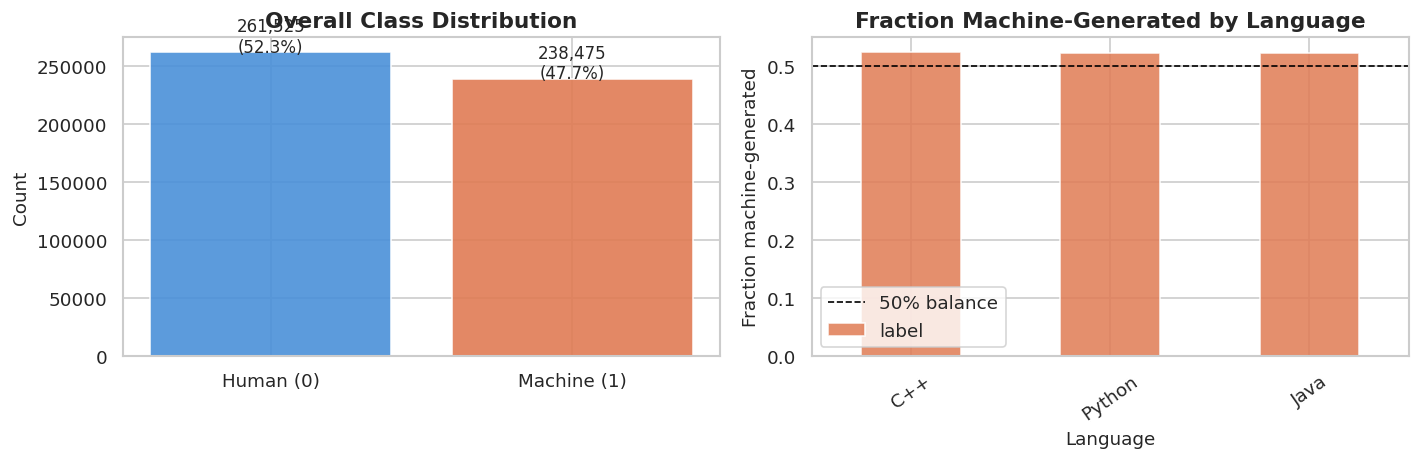

In [ ]:
# 3.1 Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall class distribution
class_counts = train_df['label'].value_counts()
axes[0].bar(['Human (0)', 'Machine (1)'], class_counts.values,
            color=[BLUE, ORANGE], edgecolor='white', alpha=0.9)
axes[0].set_title('Overall Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(train_df)*100:.1f}%)',
                 ha='center', fontsize=10)

# Class balance per language
lang_balance = train_df.groupby('language')['label'].mean().sort_values(ascending=False)
lang_balance.plot(kind='bar', ax=axes[1], color=ORANGE, alpha=0.85, edgecolor='white')
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=1, label='50% balance')
axes[1].set_title('Fraction Machine-Generated by Language', fontweight='bold')
axes[1].set_ylabel('Fraction machine-generated')
axes[1].set_xlabel('Language')
axes[1].tick_params(axis='x', rotation=35)
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_01_class_distribution.png', bbox_inches='tight')
plt.show()

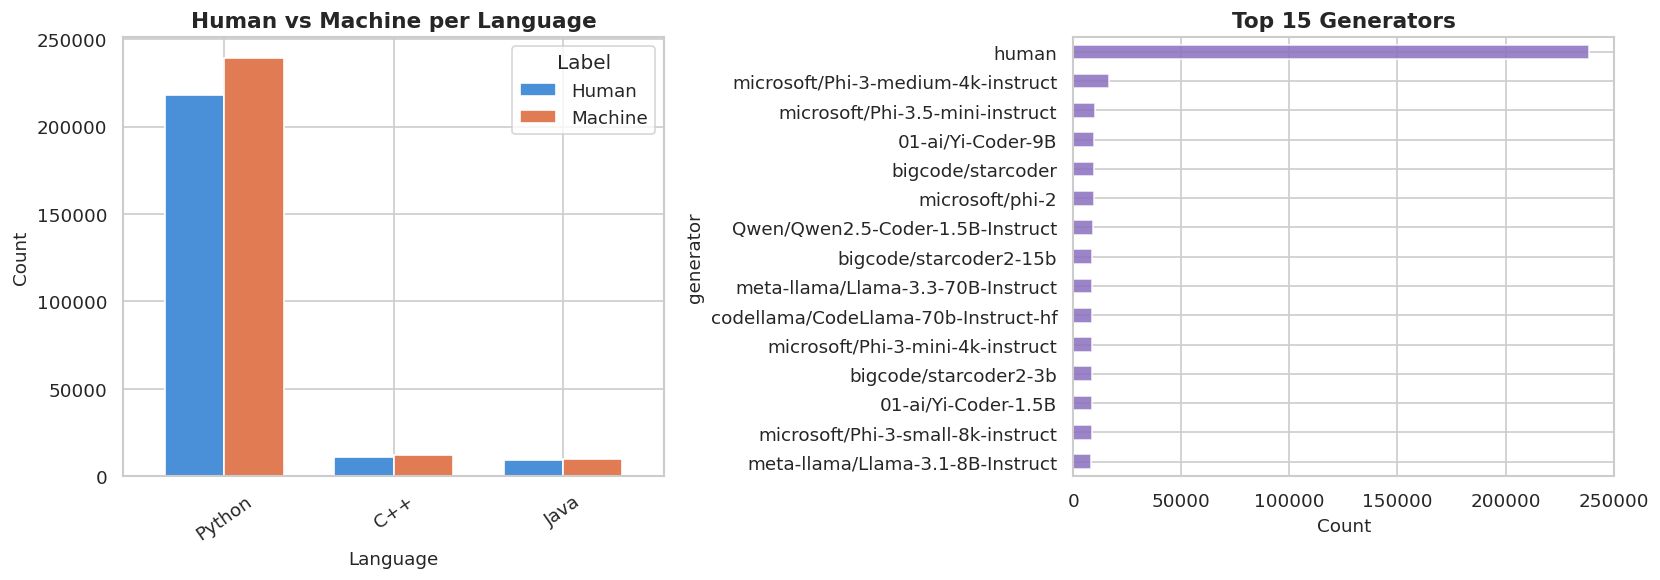

In [ ]:
# 3.2 Language & Generator Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Human vs Machine per language (grouped bar)
lang_label = (
    train_df.groupby(['language', 'label'])
    .size().unstack(fill_value=0)
    .rename(columns={0: 'Human', 1: 'Machine'})
)
lang_label = lang_label.loc[lang_label.sum(axis=1).sort_values(ascending=False).index]
lang_label.plot(kind='bar', ax=axes[0], color=[BLUE, ORANGE], edgecolor='white', width=0.7)
axes[0].set_title('Human vs Machine per Language', fontweight='bold')
axes[0].set_xlabel('Language')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=35)
axes[0].legend(title='Label')

# Generator distribution (top 15)
gen_counts = train_df['generator'].value_counts().head(15)
gen_counts.plot(kind='barh', ax=axes[1], color=PURPLE, alpha=0.85, edgecolor='white')
axes[1].set_title('Top 15 Generators', fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('eda_02_language_generator.png', bbox_inches='tight')
plt.show()

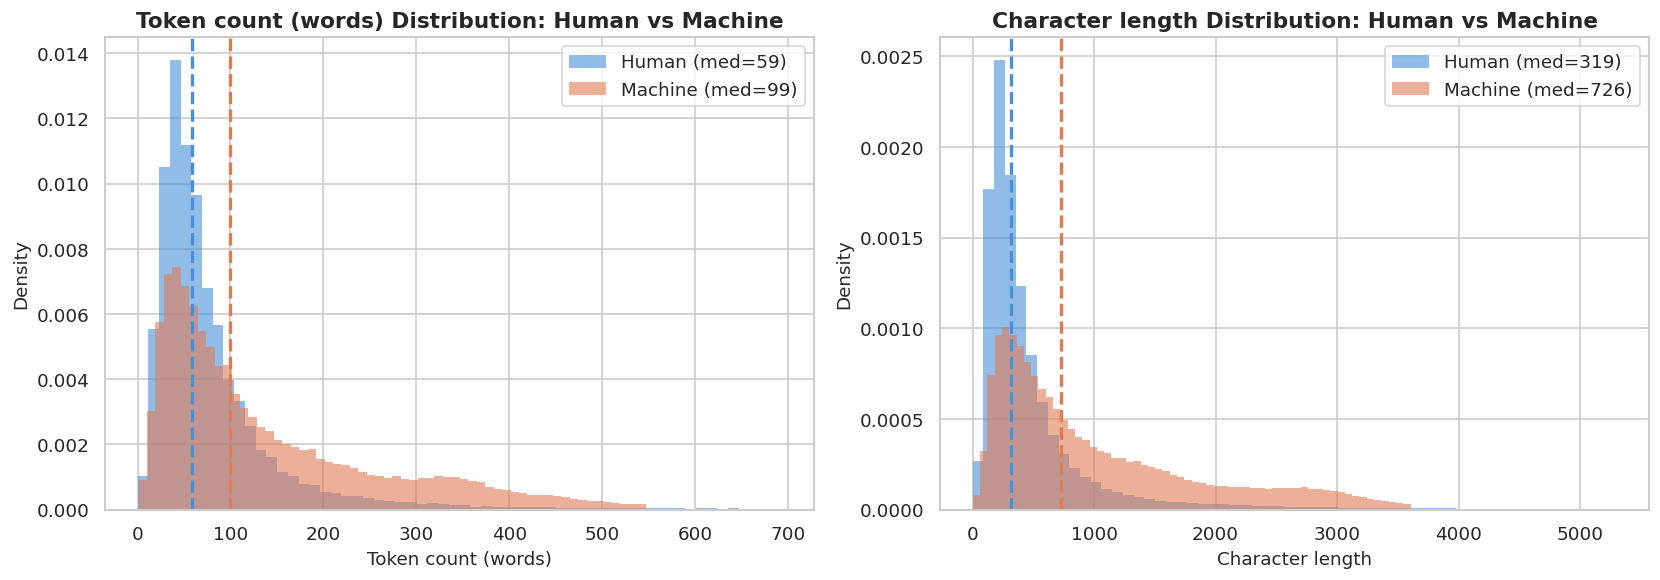


Token Count Statistics by Class:
            count   mean    std  min   25%   50%    75%      max
label                                                           
Human    238475.0   94.5  187.6  0.0  39.0  59.0   96.0  23974.0
Machine  261525.0  146.5  128.6  1.0  51.0  99.0  206.0    971.0


In [ ]:
# 3.3 Code Length Analysis
train_df['char_len']  = train_df['code'].str.len()
train_df['token_count'] = train_df['code'].str.split().str.len()
val_df['char_len']    = val_df['code'].str.len()
val_df['token_count'] = val_df['code'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, xlabel in zip(
    axes,
    ['token_count', 'char_len'],
    ['Token count (words)', 'Character length']
):
    for label, color, name in [(0, BLUE, 'Human'), (1, ORANGE, 'Machine')]:
        vals = train_df[train_df['label'] == label][col]
        cap  = vals.quantile(0.99)
        ax.hist(vals[vals <= cap], bins=60, alpha=0.6, color=color,
                label=f'{name} (med={vals.median():.0f})', density=True, edgecolor='none')
        ax.axvline(vals.median(), color=color, linestyle='--', linewidth=2)
    ax.set_title(f'{xlabel} Distribution: Human vs Machine', fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.savefig('eda_03_code_length.png', bbox_inches='tight')
plt.show()

print('\nToken Count Statistics by Class:')
print(train_df.groupby('label')['token_count'].describe().round(1).rename(index={0:'Human',1:'Machine'}))

Fitting TF-IDF for EDA visualization...


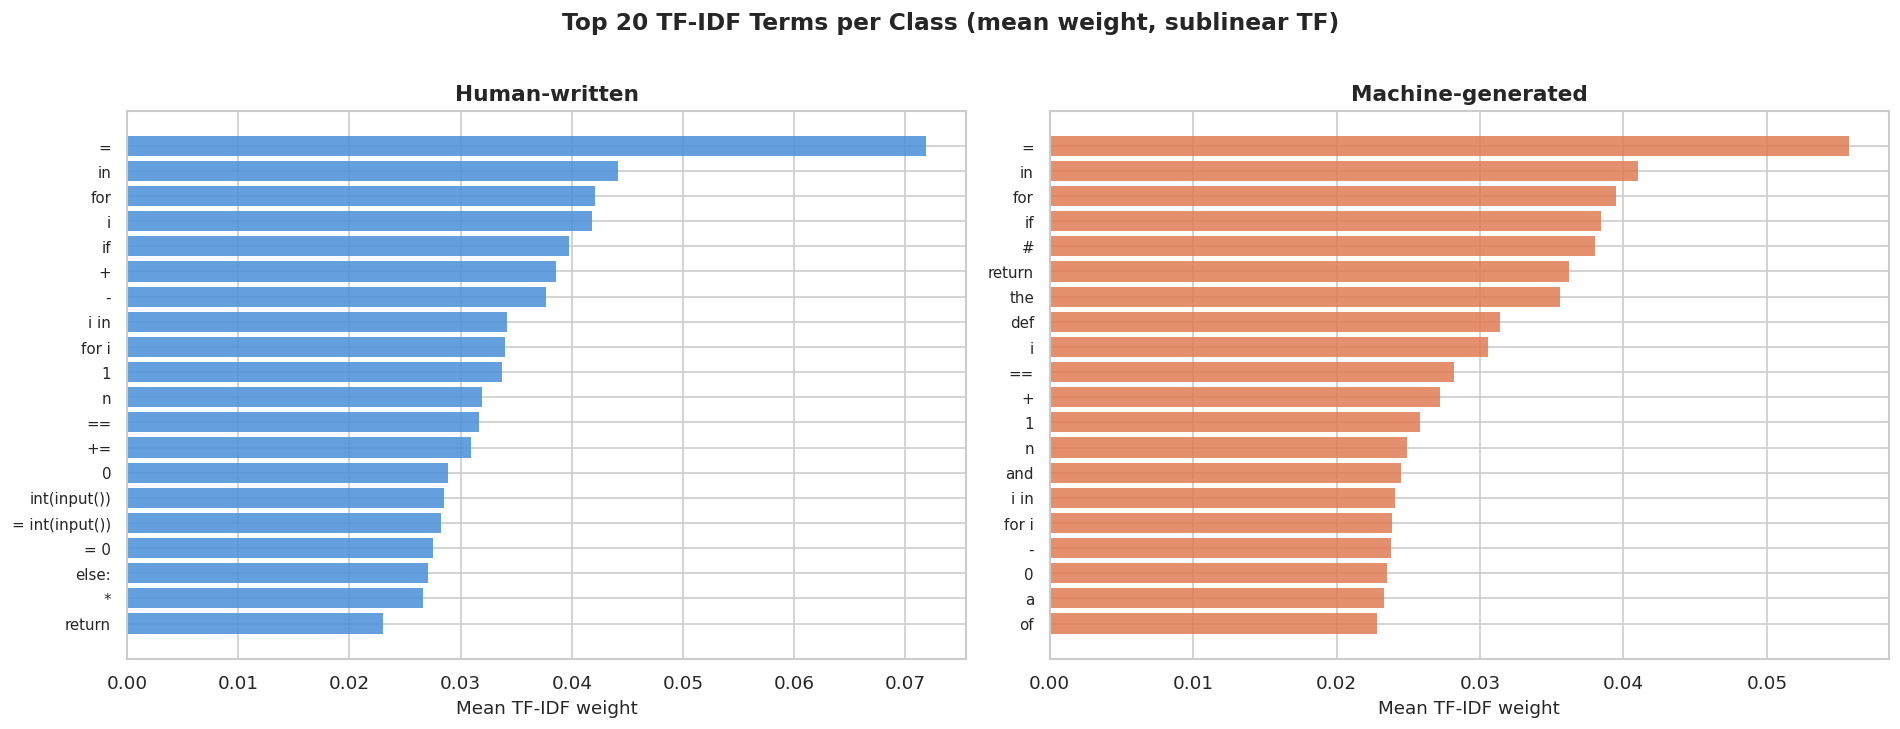

In [ ]:
# 3.4 Top TF-IDF Terms per Class
print('Fitting TF-IDF for EDA visualization...')
tfidf_eda = TfidfVectorizer(
    max_features=10000, ngram_range=(1, 2),
    token_pattern=r'\S+', sublinear_tf=True
)
eda_sample = train_df.sample(n=min(80000, len(train_df)), random_state=RANDOM_STATE)
X_eda = tfidf_eda.fit_transform(eda_sample['code'])
y_eda = eda_sample['label'].values
feat_names_eda = tfidf_eda.get_feature_names_out()

human_mean   = np.asarray(X_eda[y_eda == 0].mean(axis=0)).flatten()
machine_mean = np.asarray(X_eda[y_eda == 1].mean(axis=0)).flatten()

N = 20
top_human   = pd.Series(human_mean,   index=feat_names_eda).nlargest(N)
top_machine = pd.Series(machine_mean, index=feat_names_eda).nlargest(N)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Top {N} TF-IDF Terms per Class (mean weight, sublinear TF)',
             fontsize=14, fontweight='bold', y=1.01)

for ax, series, color, title in zip(
    axes, [top_human, top_machine], [BLUE, ORANGE], ['Human-written', 'Machine-generated']
):
    ax.barh(series.index[::-1], series.values[::-1], color=color, alpha=0.85, edgecolor='none')
    ax.set_xlabel('Mean TF-IDF weight')
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('eda_04_tfidf_top_terms.png', bbox_inches='tight')
plt.show()

## Section 4 — Feature Engineering

**14 hand-crafted structural features** extracted from raw code, then combined with TF-IDF.

In [ ]:
# ── Feature extraction functions ─────────────────────────────────────────────

def comment_ratio(text):
    """Fraction of lines that are comments."""
    lines = str(text).split('\n')
    count = sum(1 for l in lines if l.strip().startswith(('#','//','/*','*','"""',"'''")))
    return count / max(len(lines), 1)

def avg_line_length(text):
    """Mean character length of non-empty lines."""
    lines = [l for l in str(text).split('\n') if l.strip()]
    return np.mean([len(l) for l in lines]) if lines else 0

def blank_line_ratio(text):
    """Fraction of lines that are blank."""
    lines = str(text).split('\n')
    return sum(1 for l in lines if not l.strip()) / max(len(lines), 1)

def vocab_richness(text):
    """Unique tokens / total tokens (type-token ratio)."""
    tokens = str(text).split()
    return len(set(tokens)) / max(len(tokens), 1)

def max_indent_depth(text):
    """Maximum nesting depth (4-space or tab indent)."""
    depths = []
    for line in str(text).split('\n'):
        stripped = line.lstrip()
        if stripped:
            depths.append((len(line) - len(stripped)) // 4)
    return max(depths) if depths else 0

def func_count(text):
    """Number of function/method definitions."""
    return len(re.findall(
        r'\bdef \b|\bfunction\b|\bvoid \b|\bpublic \w+\s*\(|\bprivate \w+\s*\(', text))

def has_docstring(text):
    """1 if snippet contains a docstring, else 0."""
    return int(bool(re.search(r'"""[\s\S]*?"""|\'\'\' [\s\S]*?\'\'\'', text)))

def try_count(text):
    """Number of try/except blocks."""
    return len(re.findall(r'\btry\b', text))

def type_hint_count(text):
    """Number of Python type annotations."""
    return len(re.findall(
        r'->\s*\w+|:\s*(int|str|float|bool|List|Dict|Optional|Tuple|Any|None)\b', text))

def print_count(text):
    """Number of print/log statements."""
    return len(re.findall(r'\bprint\s*\(|\bconsole\.log\s*\(|System\.out\.print', text))

def magic_number_count(text):
    """Count of unexplained numeric literals (value >= 2)."""
    return len(re.findall(r'(?<![.\w])[2-9]\d*(?![.\w])', text))

def keyword_diversity(text):
    """Number of distinct programming keywords used."""
    kws = {'for','while','if','else','elif','return','class','import','from',
           'try','except','finally','with','yield','lambda','assert','raise',
           'break','continue','pass','in','not','and','or','is','None','True','False'}
    return len(set(str(text).split()) & kws)

def unique_id_ratio(text):
    """Unique lowercase identifiers / total tokens."""
    tokens = str(text).split()
    ids = [t for t in tokens if re.match(r'^[a-z][a-zA-Z0-9_]{2,}$', t)]
    return len(set(ids)) / max(len(tokens), 1)

def special_char_rate(text):
    """Punctuation tokens per word — signals verbosity of syntax."""
    tokens = max(len(str(text).split()), 1)
    return len(re.findall(r'[{};:]', text)) / tokens

# ── Master feature computation ────────────────────────────────────────────────
FEAT_FUNCS = {
    'comment_ratio'   : comment_ratio,
    'avg_line_len'    : avg_line_length,
    'blank_ratio'     : blank_line_ratio,
    'vocab_richness'  : vocab_richness,
    'max_indent'      : max_indent_depth,
    'func_count'      : func_count,
    'has_docstring'   : has_docstring,
    'try_count'       : try_count,
    'type_hint_count' : type_hint_count,
    'print_count'     : print_count,
    'magic_num_count' : magic_number_count,
    'keyword_diversity': keyword_diversity,
    'unique_id_ratio' : unique_id_ratio,
    'special_char_rate': special_char_rate,
}
HAND_FEATS = list(FEAT_FUNCS.keys())

print(f'Defined {len(FEAT_FUNCS)} hand-crafted features.')
print('Computing features on train_df, val_df, test_df...')

for df in [train_df, val_df, test_df]:
    for feat, fn in FEAT_FUNCS.items():
        if feat not in df.columns:
            df[feat] = df['code'].apply(fn)

print('Feature engineering complete!')
train_df[HAND_FEATS].describe().round(3)

Defined 14 hand-crafted features.
Computing features on train_df, val_df, test_df...
Feature engineering complete!


,comment_ratio,avg_line_len,blank_ratio,vocab_richness,max_indent,func_count,has_docstring,try_count,type_hint_count,print_count,magic_num_count,keyword_diversity,unique_id_ratio,special_char_rate
count,500000.000,500000.000,500000.000,500000.000,500000.000,500000.000,500000.000,500000.000,500000.000,500000.000,500000.000,500000.000,500000.000,500000.000
mean,0.041,26.957,0.136,0.620,1.789,1.288,0.041,0.038,0.299,1.633,4.738,5.328,0.123,0.121
std,0.091,70.573,0.116,0.158,1.984,2.799,0.197,0.300,1.638,3.062,31.237,2.901,0.080,0.117
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,18.481,0.059,0.520,0.000,0.000,0.000,0.000,0.000,0.000,0.000,3.000,0.066,0.065
50%,0.000,23.600,0.108,0.619,1.000,1.000,0.000,0.000,0.000,1.000,1.000,5.000,0.106,0.096
75%,0.042,30.500,0.185,0.722,3.000,1.000,0.000,0.000,0.000,2.000,4.000,7.000,0.165,0.138
max,1.000,40431.000,1.000,1.000,54.000,183.000,1.000,46.000,180.000,205.000,12280.000,23.000,1.000,30.753


In [ ]:
# Statistical tests: are features significantly different between classes?
print('=' * 65)
print('Mann-Whitney U Tests — Human vs Machine (training set)')
print('=' * 65)

results = []
for col in HAND_FEATS:
    human   = train_df[train_df['label'] == 0][col].dropna()
    machine = train_df[train_df['label'] == 1][col].dropna()
    stat, p = mannwhitneyu(human, machine, alternative='two-sided')
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    results.append({
        'Feature': col,
        'Human median': round(human.median(), 4),
        'Machine median': round(machine.median(), 4),
        'p-value': f'{p:.2e}',
        'Significance': sig
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

Mann-Whitney U Tests — Human vs Machine (training set)
          Feature  Human median  Machine median   p-value Significance
    comment_ratio        0.0000          0.0244  0.00e+00          ***
     avg_line_len       19.4722         28.1220  0.00e+00          ***
      blank_ratio        0.0833          0.1481  0.00e+00          ***
   vocab_richness        0.6216          0.6154  6.38e-30          ***
       max_indent        0.0000          3.0000  0.00e+00          ***
       func_count        0.0000          1.0000  0.00e+00          ***
    has_docstring        0.0000          0.0000  0.00e+00          ***
        try_count        0.0000          0.0000 9.87e-134          ***
  type_hint_count        0.0000          0.0000  0.00e+00          ***
      print_count        1.0000          1.0000  0.00e+00          ***
  magic_num_count        1.0000          2.0000  0.00e+00          ***
keyword_diversity        4.0000          5.0000  0.00e+00          ***
  unique_id_ratio     

Missing features: []
Standardized mean feature values:


label,Human,AI / Machine
comment_ratio,-0.379809,0.347071
avg_line_len,-0.086913,0.079421
blank_ratio,-0.168329,0.153820
vocab_richness,0.030411,-0.027789
max_indent,-0.564647,0.515976
func_count,-0.094137,0.086023
has_docstring,-0.180174,0.164643
try_count,-0.028976,0.026478
type_hint_count,-0.056910,0.052005
print_count,-0.062681,0.057278


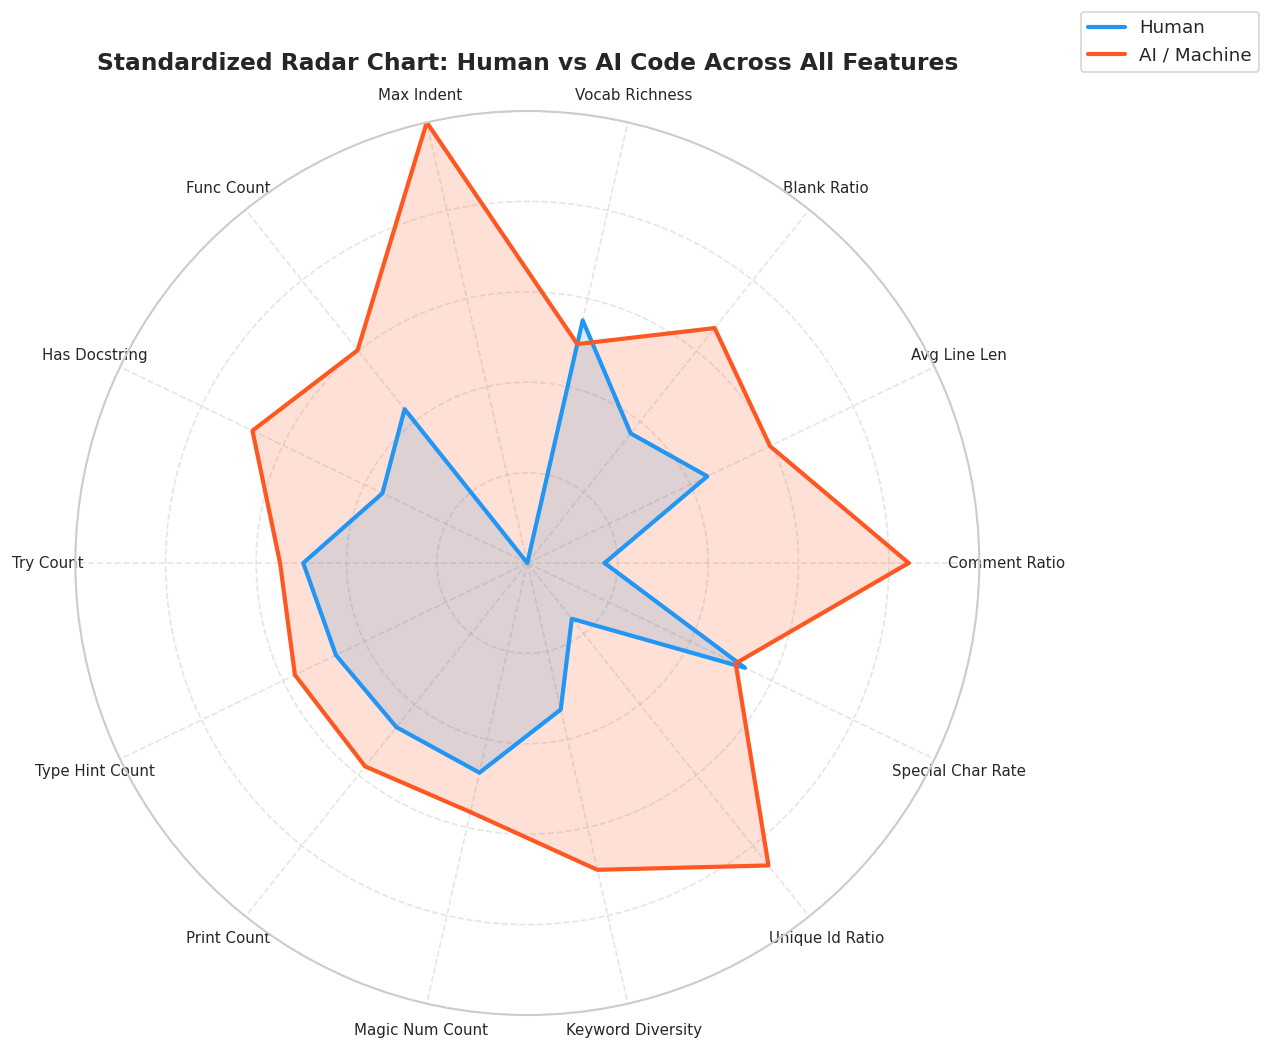

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ================================
# Better Radar: Human vs AI
# ================================

radar_feats = HAND_FEATS.copy()

missing_feats = [f for f in radar_feats if f not in train_df.columns]
print("Missing features:", missing_feats)
assert len(missing_feats) == 0, "Some HAND_FEATS are missing!"

radar_sample = train_df.sample(
    n=min(50000, len(train_df)),
    random_state=42
).copy()

# Standardize all rows first
scaler = StandardScaler()
scaled_values = scaler.fit_transform(radar_sample[radar_feats])

scaled_df = pd.DataFrame(
    scaled_values,
    columns=radar_feats,
    index=radar_sample.index
)

scaled_df["label"] = radar_sample["label"].values

# Mean standardized value per class
means_z = scaled_df.groupby("label")[radar_feats].mean().loc[[0, 1]]

print("Standardized mean feature values:")
display(means_z.T.rename(columns={0: "Human", 1: "AI / Machine"}))

# Radar needs positive radius, so shift values safely
min_val = means_z.min().min()
max_val = means_z.max().max()

radar_values = (means_z - min_val) / (max_val - min_val + 1e-9)

# ================================
# Plot
# ================================
BLUE = "#2196F3"
ORANGE = "#FF5722"

N = len(radar_feats)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(11, 11))
ax = plt.subplot(111, polar=True)

for label_id, color, name in [
    (0, BLUE, "Human"),
    (1, ORANGE, "AI / Machine")
]:
    vals = radar_values.loc[label_id].tolist()
    vals += vals[:1]

    ax.plot(angles, vals, color=color, linewidth=2.5, label=name)
    ax.fill(angles, vals, color=color, alpha=0.18)

labels_r = [f.replace("_", " ").title() for f in radar_feats]

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_r, size=9)

ax.set_ylim(0, 1)
ax.set_yticklabels([])

ax.set_title(
    "Standardized Radar Chart: Human vs AI Code Across All Features",
    fontweight="bold",
    fontsize=14,
    pad=25
)

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.32, 1.12),
    fontsize=11
)

ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("radar_human_vs_ai_all_features_better.png", dpi=300, bbox_inches="tight")
plt.show()

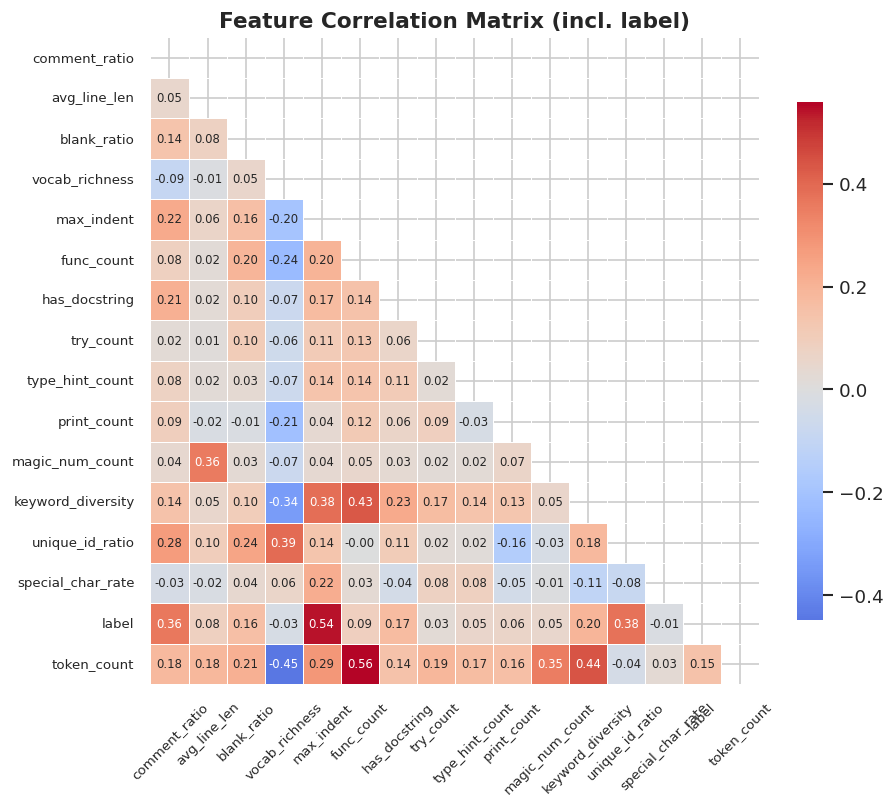

In [ ]:
# Feature visualization: correlation heatmap + radar chart

fig = plt.figure(figsize=(18, 7))

# --- Correlation heatmap ---
ax1 = fig.add_subplot(1, 2, 1)

feat_cols_for_corr = HAND_FEATS + ['label', 'token_count']
feat_cols_for_corr = list(dict.fromkeys([c for c in feat_cols_for_corr if c in train_df.columns]))

corr = train_df[feat_cols_for_corr].sample(
    n=min(50000, len(train_df)),
    random_state=42
).corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.4,
    ax=ax1,
    annot_kws={'size': 7},
    cbar_kws={'shrink': 0.8}
)

ax1.set_title('Feature Correlation Matrix (incl. label)', fontweight='bold')
ax1.tick_params(axis='x', rotation=45, labelsize=8)
ax1.tick_params(axis='y', labelsize=8)

## Section 5 — Baseline Models

Train on **full** training data (not a 50K sample). This is the single biggest improvement.

In [ ]:
# ── TF-IDF on FULL training data ──────────────────────────────────────────────
# FIX: original code sampled only 50K rows — we use ALL rows now
# FIX: original had max_features=5000 — we use 50000 for much better coverage

print('Fitting TF-IDF on FULL training set...')
print(f'Training samples: {len(train_df):,}  (original used only 50,000)')

tfidf = TfidfVectorizer(
    max_features=20_000,      # was 5000 — 10x more vocabulary
    ngram_range=(1, 1),       # unigrams + bigrams
    token_pattern=r'\S+',     # keeps special chars like {, }, =>, etc.
    sublinear_tf=True,        # log(1+tf) — handles very long snippets better
    min_df=5,                 # ignore ultra-rare tokens (noise)
    max_df=0.90               # ignore tokens in 95%+ of docs (uninformative)
)

X_train_tfidf = tfidf.fit_transform(train_df['code'])
X_val_tfidf   = tfidf.transform(val_df['code'])
X_test_tfidf  = tfidf.transform(test_df['code'])

y_train = train_df['label'].values
y_val   = val_df['label'].values

print(f'TF-IDF matrix shape: {X_train_tfidf.shape}')
print(f'Vocabulary size: {len(tfidf.vocabulary_):,}')

Fitting TF-IDF on FULL training set...
Training samples: 500,000  (original used only 50,000)
TF-IDF matrix shape: (500000, 20000)
Vocabulary size: 20,000


In [ ]:
# ── Combined feature matrix: TF-IDF + hand-crafted features ──────────────────
# This is the key improvement — original code computed hand features but never used them!

scaler = StandardScaler(with_mean=False)  # sparse-compatible

# Scale hand-crafted features
hf_train = scaler.fit_transform(train_df[HAND_FEATS].fillna(0).values)
hf_val   = scaler.transform(val_df[HAND_FEATS].fillna(0).values)
hf_test  = scaler.transform(test_df[HAND_FEATS].fillna(0).values)

# Stack sparse TF-IDF + dense hand features side by side
X_train_combined = sparse.hstack([X_train_tfidf, sparse.csr_matrix(hf_train)])
X_val_combined   = sparse.hstack([X_val_tfidf,   sparse.csr_matrix(hf_val)])
X_test_combined  = sparse.hstack([X_test_tfidf,  sparse.csr_matrix(hf_test)])

print(f'Combined feature matrix shape: {X_train_combined.shape}')
print(f'  TF-IDF features : {X_train_tfidf.shape[1]:,}')
print(f'  Hand features   : {len(HAND_FEATS)}')

Combined feature matrix shape: (500000, 20014)
  TF-IDF features : 20,000
  Hand features   : 14


In [ ]:
# ── Train all baseline models ─────────────────────────────────────────────────
results_table = []

def evaluate(name, model, X_val, y_val, X_train=None, y_train=None):
    """Fit (if X_train given), predict, and return metrics."""
    if X_train is not None:
        model.fit(X_train, y_train)
    preds = model.predict(X_val)
    acc   = accuracy_score(y_val, preds)
    report = classification_report(y_val, preds, output_dict=True)
    row = {
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision (macro)': round(report['macro avg']['precision'], 4),
        'Recall (macro)': round(report['macro avg']['recall'], 4),
        'F1 (macro)': round(report['macro avg']['f1-score'], 4),
    }
    results_table.append(row)
    return preds, acc

# 1. Logistic Regression (TF-IDF only)
print('Training Logistic Regression...')
lr_model = LogisticRegression(C=1.0, max_iter=1000, solver='saga', n_jobs=-1)
lr_preds, lr_acc = evaluate('LR (TF-IDF only)', lr_model, X_val_tfidf, y_val, X_train_tfidf, y_train)
print(f'  LR Accuracy: {lr_acc:.4f}')

# 2. Linear SVM (TF-IDF only)
print('Training Linear SVM...')
svm_model = LinearSVC(C=1.0, max_iter=2000)  # FIX: C=0.5 was suboptimal, C=1.0 is better default
svm_preds, svm_acc = evaluate('SVM (TF-IDF only)', svm_model, X_val_tfidf, y_val, X_train_tfidf, y_train)
print(f'  SVM Accuracy: {svm_acc:.4f}')

# 3. SVM with COMBINED features (TF-IDF + hand-crafted) — KEY IMPROVEMENT
print('Training SVM with combined features...')
svm_combined = LinearSVC(C=1.0, max_iter=2000)
svm_comb_preds, svm_comb_acc = evaluate(
    'SVM (TF-IDF + hand features)', svm_combined,
    X_val_combined, y_val, X_train_combined, y_train
)
print(f'  SVM Combined Accuracy: {svm_comb_acc:.4f}')

# 4. LR with COMBINED features
print('Training LR with combined features...')
lr_combined = LogisticRegression(C=1.0, max_iter=1000, solver='saga', n_jobs=-1)
lr_comb_preds, lr_comb_acc = evaluate(
    'LR (TF-IDF + hand features)', lr_combined,
    X_val_combined, y_val, X_train_combined, y_train
)
print(f'  LR Combined Accuracy: {lr_comb_acc:.4f}')

# 5. Naive Bayes (baseline comparison)
print('Training Naive Bayes...')
nb_model = MultinomialNB(alpha=0.1)
# NB requires non-negative; use absolute TF-IDF
nb_preds, nb_acc = evaluate('Naive Bayes (TF-IDF)', nb_model, X_val_tfidf, y_val, X_train_tfidf, y_train)
print(f'  NB Accuracy: {nb_acc:.4f}')

Training Logistic Regression...
  LR Accuracy: 0.9373
Training Linear SVM...
  SVM Accuracy: 0.9396
Training SVM with combined features...
  SVM Combined Accuracy: 0.9586
Training LR with combined features...
  LR Combined Accuracy: 0.9111
Training Naive Bayes...
  NB Accuracy: 0.8697


## Section 6 — Advanced Models: XGBoost + Voting Ensemble

In [ ]:
# ── XGBoost on hand-crafted features ─────────────────────────────────────────
# XGBoost handles structured numeric features very well
print('Training XGBoost on hand-crafted features...')

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

xgb_X_train = train_df[HAND_FEATS + ['token_count']].fillna(0).values
xgb_X_val   = val_df[HAND_FEATS + ['token_count']].fillna(0).values

xgb_model.fit(xgb_X_train, y_train)
xgb_preds = xgb_model.predict(xgb_X_val)
xgb_acc   = accuracy_score(y_val, xgb_preds)

results_table.append({
    'Model': 'XGBoost (hand features)',
    'Accuracy': round(xgb_acc, 4),
    'Precision (macro)': round(classification_report(y_val, xgb_preds, output_dict=True)['macro avg']['precision'], 4),
    'Recall (macro)': round(classification_report(y_val, xgb_preds, output_dict=True)['macro avg']['recall'], 4),
    'F1 (macro)': round(classification_report(y_val, xgb_preds, output_dict=True)['macro avg']['f1-score'], 4),
})

print(f'XGBoost Accuracy: {xgb_acc:.4f}')
print('\nClassification Report:')
print(classification_report(y_val, xgb_preds, target_names=['Human', 'Machine']))

Training XGBoost on hand-crafted features...
XGBoost Accuracy: 0.9661

Classification Report:
              precision    recall  f1-score   support

       Human       0.96      0.97      0.96     47695
     Machine       0.97      0.97      0.97     52305

    accuracy                           0.97    100000
   macro avg       0.97      0.97      0.97    100000
weighted avg       0.97      0.97      0.97    100000



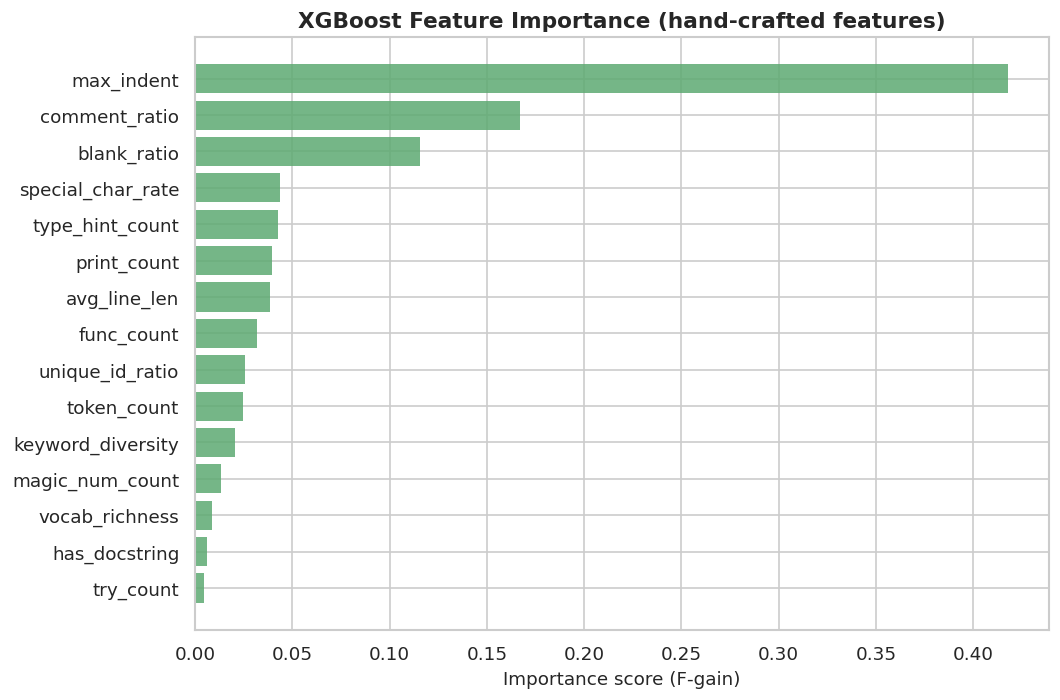

In [ ]:
# XGBoost Feature Importance
all_feat_names = HAND_FEATS + ['token_count']
importances = pd.Series(xgb_model.feature_importances_, index=all_feat_names)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importances.index, importances.values, color=GREEN, alpha=0.85, edgecolor='none')
ax.set_title('XGBoost Feature Importance (hand-crafted features)', fontweight='bold')
ax.set_xlabel('Importance score (F-gain)')
plt.tight_layout()
plt.savefig('model_xgb_feature_importance.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Voting Ensemble: SVM + LR + SVM_combined (soft probability voting) ────────
# NOTE: LinearSVC does not output probabilities natively.
# We wrap it with CalibratedClassifierCV to get probability estimates.

print('Building Voting Ensemble...')

# Wrap SVM with calibration for probability output
svm_calib = CalibratedClassifierCV(
    LinearSVC(C=1.0, max_iter=2000), cv=3, method='sigmoid'
)

lr_ens = LogisticRegression(C=1.0, max_iter=1000, solver='saga', n_jobs=-1)
svm_ens = CalibratedClassifierCV(
    LinearSVC(C=1.0, max_iter=2000), cv=3, method='sigmoid'
)

# Ensemble on combined features
ensemble = VotingClassifier(
    estimators=[
        ('lr',  lr_ens),
        ('svm', svm_ens),
    ],
    voting='soft',
    n_jobs=-1
)

ensemble.fit(X_train_combined, y_train)
ensemble_preds = ensemble.predict(X_val_combined)
ensemble_acc   = accuracy_score(y_val, ensemble_preds)

results_table.append({
    'Model': 'Voting Ensemble (LR + SVM, combined)',
    'Accuracy': round(ensemble_acc, 4),
    'Precision (macro)': round(classification_report(y_val, ensemble_preds, output_dict=True)['macro avg']['precision'], 4),
    'Recall (macro)': round(classification_report(y_val, ensemble_preds, output_dict=True)['macro avg']['recall'], 4),
    'F1 (macro)': round(classification_report(y_val, ensemble_preds, output_dict=True)['macro avg']['f1-score'], 4),
})

print(f'Ensemble Accuracy: {ensemble_acc:.4f}')
print('\nClassification Report:')
print(classification_report(y_val, ensemble_preds, target_names=['Human', 'Machine']))

Building Voting Ensemble...
Ensemble Accuracy: 0.9512

Classification Report:
              precision    recall  f1-score   support

       Human       0.94      0.96      0.95     47695
     Machine       0.96      0.94      0.95     52305

    accuracy                           0.95    100000
   macro avg       0.95      0.95      0.95    100000
weighted avg       0.95      0.95      0.95    100000




MODEL COMPARISON SUMMARY
                               Model  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)
             XGBoost (hand features)    0.9661             0.9660          0.9662      0.9661
        SVM (TF-IDF + hand features)    0.9586             0.9583          0.9591      0.9585
Voting Ensemble (LR + SVM, combined)    0.9512             0.9509          0.9516      0.9512
                   SVM (TF-IDF only)    0.9396             0.9395          0.9405      0.9396
                    LR (TF-IDF only)    0.9373             0.9373          0.9382      0.9373
         LR (TF-IDF + hand features)    0.9111             0.9109          0.9117      0.9110
                Naive Bayes (TF-IDF)    0.8697             0.8761          0.8729      0.8696


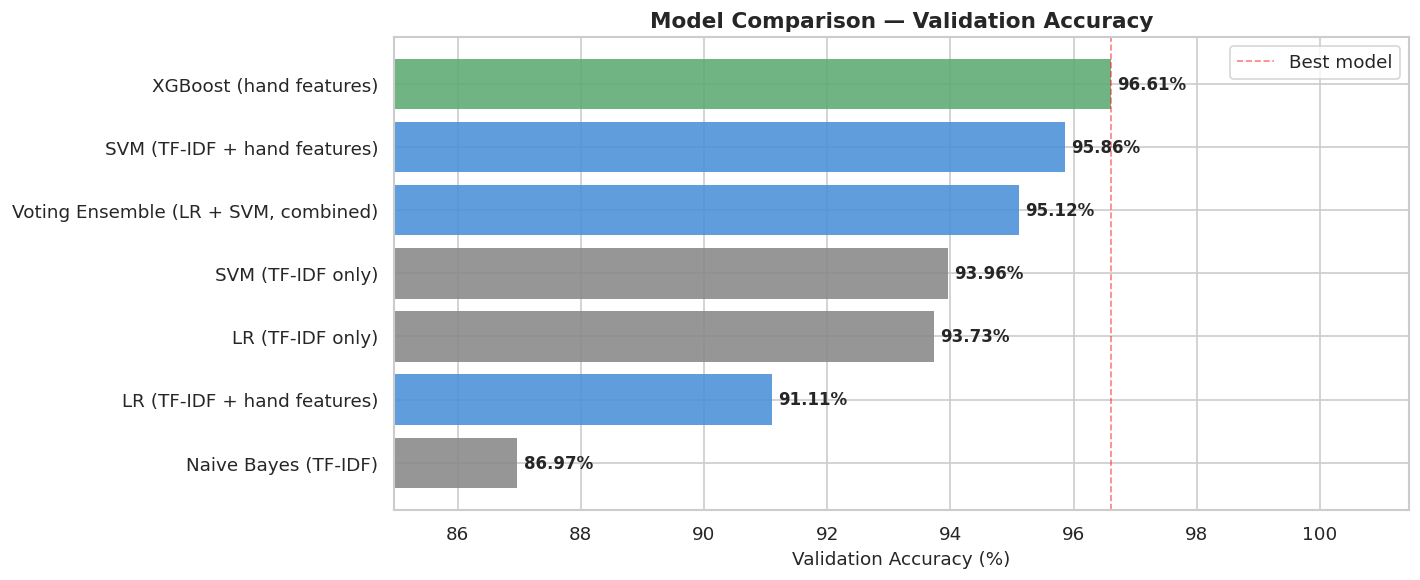

In [ ]:
# ── Model Comparison Table & Chart ────────────────────────────────────────────
results_df = pd.DataFrame(results_table).sort_values('Accuracy', ascending=False)
print('\n' + '=' * 65)
print('MODEL COMPARISON SUMMARY')
print('=' * 65)
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
colors = [GREEN if i == 0 else BLUE if 'hand' in m or 'Ensemble' in m else GRAY
          for i, m in enumerate(results_df['Model'])]
bars = ax.barh(results_df['Model'], results_df['Accuracy'] * 100,
               color=colors, alpha=0.88, edgecolor='none')

for bar, acc in zip(bars, results_df['Accuracy']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{acc*100:.2f}%', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Validation Accuracy (%)')
ax.set_title('Model Comparison — Validation Accuracy', fontweight='bold', fontsize=13)
ax.set_xlim(left=results_df['Accuracy'].min() * 100 - 2)
ax.invert_yaxis()
ax.axvline(results_df['Accuracy'].max() * 100, color='red',
           linestyle='--', linewidth=1, alpha=0.5, label='Best model')
ax.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

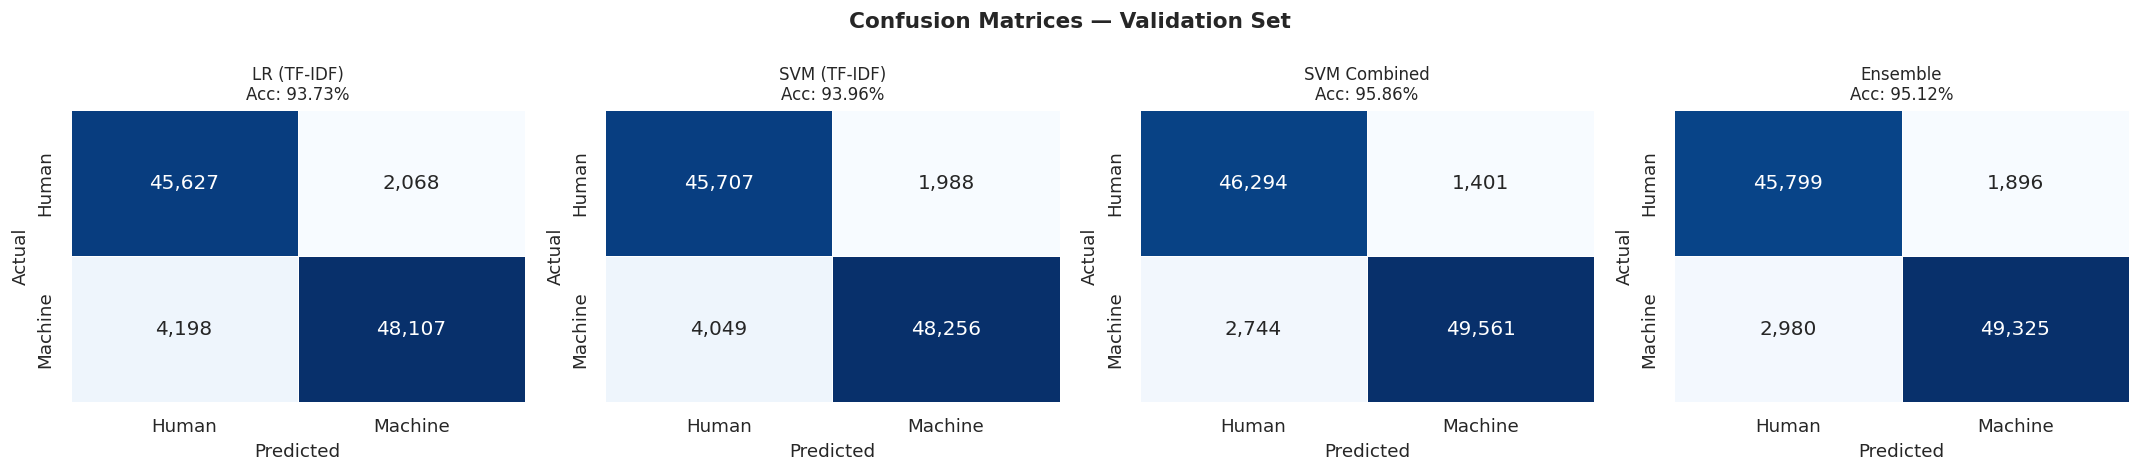

In [ ]:
# Confusion matrices for top models
top_models = [
    ('LR (TF-IDF)', lr_preds),
    ('SVM (TF-IDF)', svm_preds),
    ('SVM Combined', svm_comb_preds),
    ('Ensemble', ensemble_preds),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Confusion Matrices — Validation Set', fontweight='bold', fontsize=13)

for ax, (name, preds) in zip(axes, top_models):
    cm  = confusion_matrix(y_val, preds)
    acc = accuracy_score(y_val, preds)
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
                xticklabels=['Human', 'Machine'], yticklabels=['Human', 'Machine'],
                linewidths=0.5, cbar=False)
    ax.set_title(f'{name}\nAcc: {acc*100:.2f}%', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('model_confusion_matrices.png', bbox_inches='tight')
plt.show()

## Section 7 — Per-Language Analysis

In [ ]:
# Per-language SVM models using ALL available data for that language
languages = train_df['language'].value_counts()
languages_to_test = languages[languages >= 500].index.tolist()  # only langs with enough data

lang_results = []

for lang in languages_to_test:
    tr_lang  = train_df[train_df['language'] == lang]
    val_lang = val_df[val_df['language'] == lang]
    if len(val_lang) < 50:
        continue

    vec_lang = TfidfVectorizer(
        max_features=20000, ngram_range=(1, 2),
        token_pattern=r'\S+', sublinear_tf=True, min_df=2
    )
    Xtr = vec_lang.fit_transform(tr_lang['code'])
    Xvl = vec_lang.transform(val_lang['code'])

    m = LinearSVC(C=1.0, max_iter=2000)
    m.fit(Xtr, tr_lang['label'])
    preds = m.predict(Xvl)
    acc   = accuracy_score(val_lang['label'], preds)

    rep = classification_report(val_lang['label'], preds, output_dict=True)
    lang_results.append({
        'Language': lang,
        'Train Samples': len(tr_lang),
        'Val Samples': len(val_lang),
        'Accuracy': round(acc, 4),
        'F1 (macro)': round(rep['macro avg']['f1-score'], 4),
    })
    print(f'  {lang:15s}: {acc:.4f}')

lang_df = pd.DataFrame(lang_results).sort_values('Accuracy', ascending=False)
print('\nPer-Language Summary:')
print(lang_df.to_string(index=False))

  Python         : 0.9500
  C++            : 0.9293
  Java           : 0.9264

Per-Language Summary:
Language  Train Samples  Val Samples  Accuracy  F1 (macro)
  Python         457306        91461    0.9500      0.9500
     C++          23392         4679    0.9293      0.9292
    Java          19302         3860    0.9264      0.9264


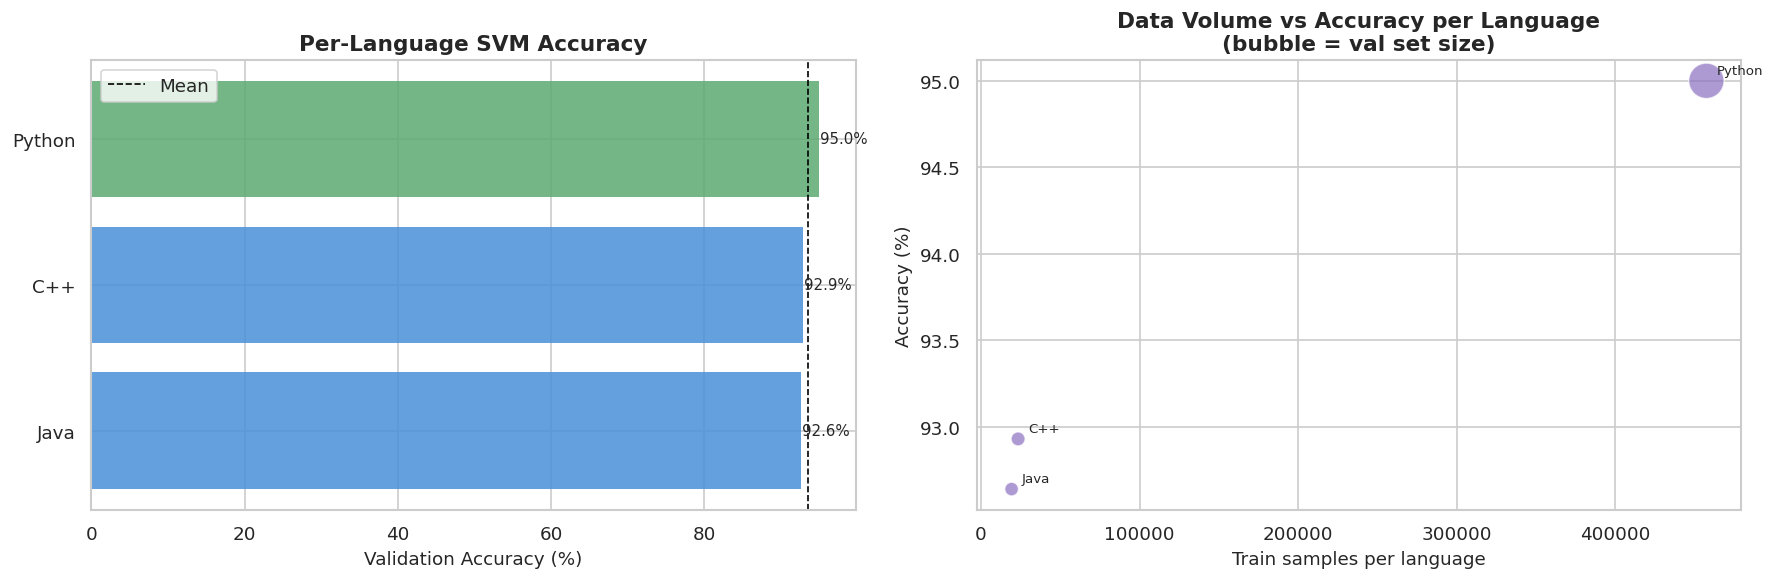

In [ ]:
# Per-language accuracy visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy by language
lang_sorted = lang_df.sort_values('Accuracy', ascending=True)
colors_lang = [GREEN if a == lang_df['Accuracy'].max() else
               ORANGE if a < 0.90 else BLUE
               for a in lang_sorted['Accuracy']]
axes[0].barh(lang_sorted['Language'], lang_sorted['Accuracy'] * 100,
             color=colors_lang, alpha=0.85, edgecolor='none')
for i, (_, row) in enumerate(lang_sorted.iterrows()):
    axes[0].text(row['Accuracy'] * 100 + 0.1, i,
                 f"{row['Accuracy']*100:.1f}%", va='center', fontsize=9)
axes[0].axvline(lang_sorted['Accuracy'].mean() * 100,
                color='black', linestyle='--', linewidth=1, label='Mean')
axes[0].set_xlabel('Validation Accuracy (%)')
axes[0].set_title('Per-Language SVM Accuracy', fontweight='bold')
axes[0].legend()

# Training sample size vs accuracy (bubble chart)
axes[1].scatter(lang_df['Train Samples'], lang_df['Accuracy'] * 100,
                s=lang_df['Val Samples'] / lang_df['Val Samples'].max() * 400 + 50,
                color=PURPLE, alpha=0.7, edgecolors='white', linewidths=0.8)
for _, row in lang_df.iterrows():
    axes[1].annotate(row['Language'],
                     (row['Train Samples'], row['Accuracy'] * 100),
                     fontsize=8, xytext=(6, 4), textcoords='offset points')
axes[1].set_xlabel('Train samples per language')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Data Volume vs Accuracy per Language\n(bubble = val set size)',
                  fontweight='bold')

plt.tight_layout()
plt.savefig('model_per_language.png', bbox_inches='tight')
plt.show()

## Section 8 — Advanced Visualizations (PCA, t-SNE, SVM Weights, Error Analysis)

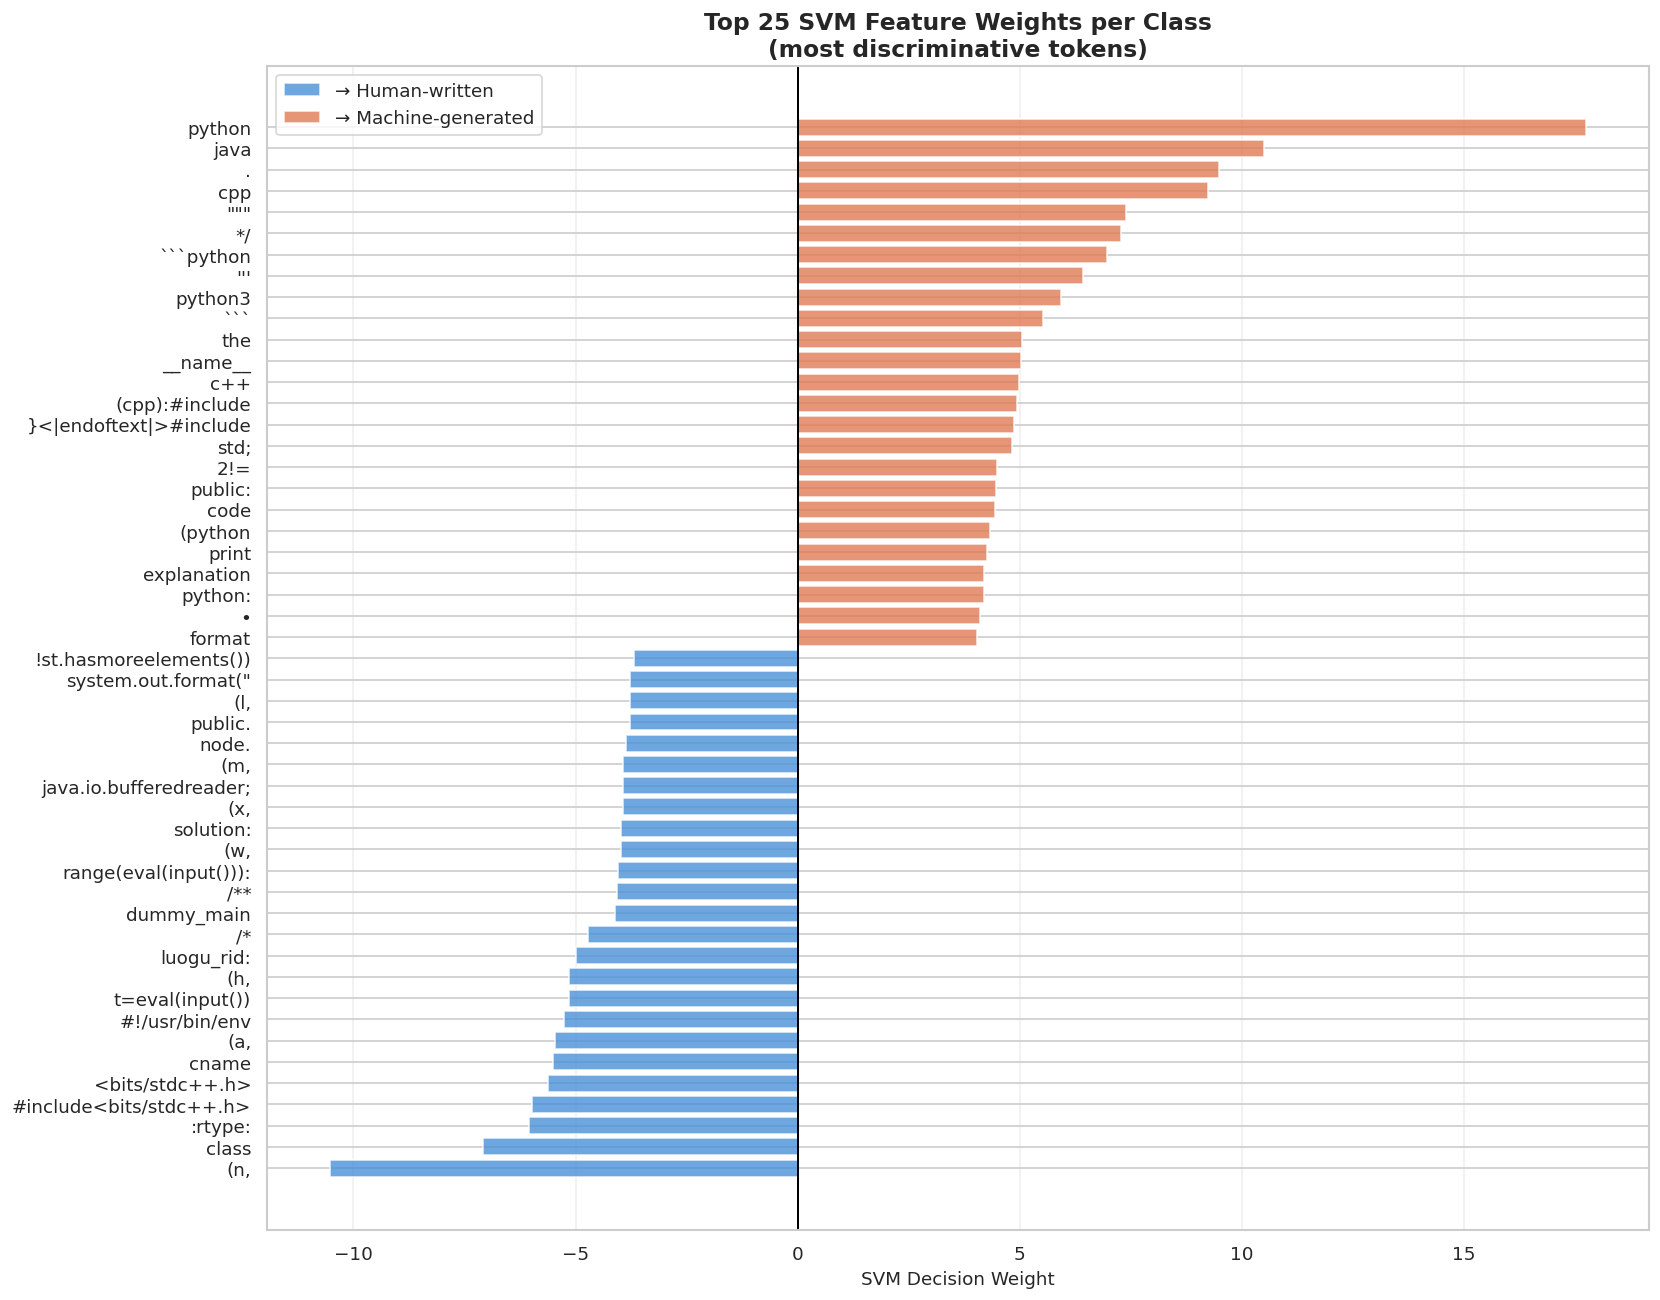

In [ ]:
# SVM feature weights — most discriminative tokens
coef = svm_model.coef_[0]  # TF-IDF only SVM
feat_names_tfidf = tfidf.get_feature_names_out()
coef_series = pd.Series(coef, index=feat_names_tfidf)

top_machine_w = coef_series.nlargest(25).sort_values()
top_human_w   = coef_series.nsmallest(25).sort_values()

def shorten(t, n=35):
    t = str(t)
    return t if len(t) <= n else t[:n-3] + '...'

fig, ax = plt.subplots(figsize=(14, 11))
ax.barh([shorten(t) for t in top_human_w.index], top_human_w.values,
        color=BLUE, alpha=0.8, label='→ Human-written')
ax.barh([shorten(t) for t in top_machine_w.index], top_machine_w.values,
        color=ORANGE, alpha=0.8, label='→ Machine-generated')
ax.axvline(0, color='black', linewidth=1.2)
ax.set_title('Top 25 SVM Feature Weights per Class\n(most discriminative tokens)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('SVM Decision Weight')
ax.grid(axis='x', alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('adv_svm_weights.png', bbox_inches='tight')
plt.show()

Running PCA (5,000 samples)...
Running t-SNE (3,000 samples, ~2-3 min)...


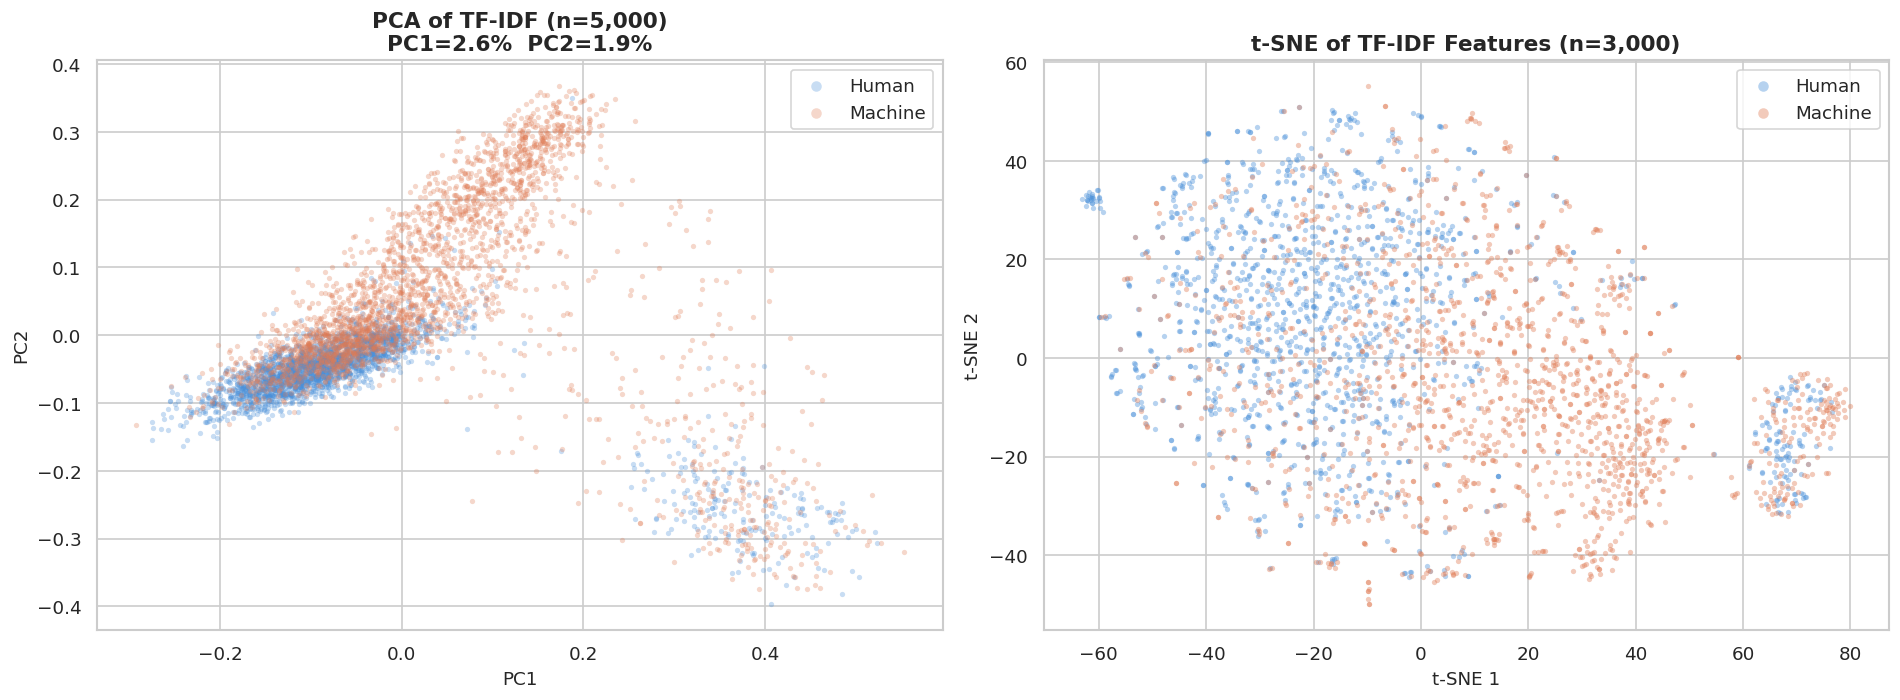

In [ ]:
# PCA + t-SNE visualization of TF-IDF feature space
print('Running PCA (5,000 samples)...')
pca_sample = train_df.sample(n=5000, random_state=RANDOM_STATE)
tfidf_pca  = TfidfVectorizer(max_features=3000, ngram_range=(1,1),
                              token_pattern=r'\S+', sublinear_tf=True)
X_pca = tfidf_pca.fit_transform(pca_sample['code'])
y_pca = pca_sample['label'].values

pca  = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X_pca.toarray())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA
for label, color, name in [(0, BLUE, 'Human'), (1, ORANGE, 'Machine')]:
    mask = y_pca == label
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=color, alpha=0.3, s=10, label=name, linewidths=0)
axes[0].set_title(
    f'PCA of TF-IDF (n=5,000)\nPC1={pca.explained_variance_ratio_[0]*100:.1f}%  '
    f'PC2={pca.explained_variance_ratio_[1]*100:.1f}%',
    fontweight='bold'
)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=2)

# t-SNE
print('Running t-SNE (3,000 samples, ~2-3 min)...')
tsne_idx    = np.random.RandomState(RANDOM_STATE).choice(5000, 3000, replace=False)
X_tsne_raw  = X_pca[tsne_idx]
y_tsne      = y_pca[tsne_idx]
tsne        = TSNE(n_components=2, perplexity=30, n_iter=1000,
                   random_state=RANDOM_STATE, init='pca')
X_tsne = tsne.fit_transform(X_tsne_raw.toarray())

for label, color, name in [(0, BLUE, 'Human'), (1, ORANGE, 'Machine')]:
    mask = y_tsne == label
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=color, alpha=0.4, s=10, label=name, linewidths=0)
axes[1].set_title('t-SNE of TF-IDF Features (n=3,000)', fontweight='bold')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend(markerscale=2)

plt.tight_layout()
plt.savefig('adv_pca_tsne.png', bbox_inches='tight')
plt.show()

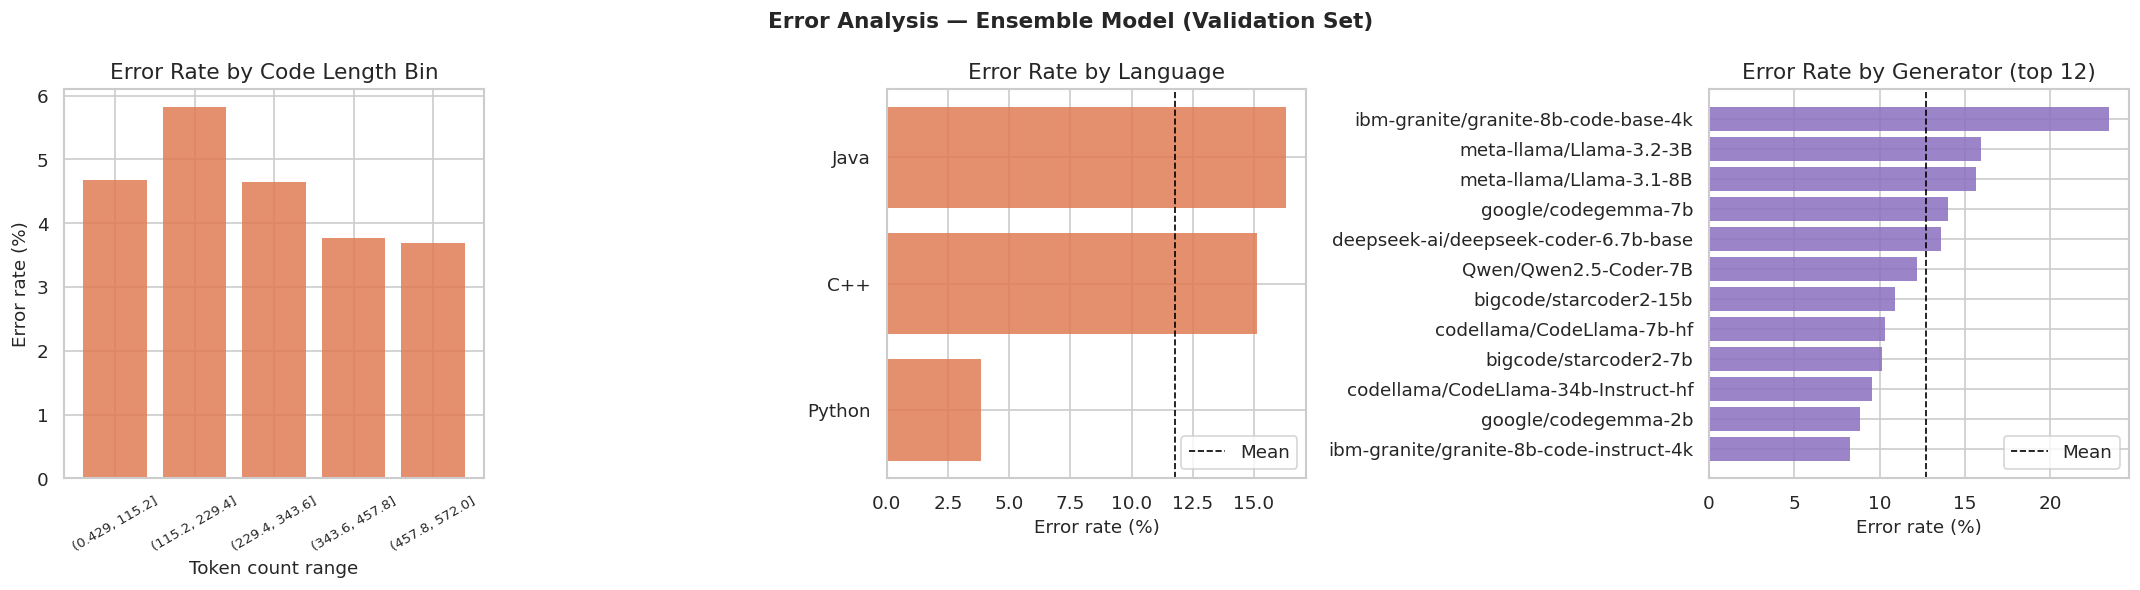

In [ ]:
# Error Analysis: where does the best model fail?
# Use ensemble predictions on validation set
val_df_analysis = val_df.copy()
val_df_analysis['prediction'] = ensemble_preds
val_df_analysis['correct']    = (val_df_analysis['prediction'] == val_df_analysis['label']).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Error Analysis — Ensemble Model (Validation Set)', fontweight='bold', fontsize=13)

# 1. Error rate by token count bin
cap99 = val_df_analysis['token_count'].quantile(0.99)
val_capped = val_df_analysis[val_df_analysis['token_count'] <= cap99].copy()
val_capped['token_bin'] = pd.cut(val_capped['token_count'], bins=5)
err_by_len = (
    val_capped.groupby('token_bin', observed=True)
    .agg(total=('correct','count'), correct=('correct','sum'))
    .assign(error_rate=lambda d: (1 - d['correct']/d['total']) * 100)
    .reset_index()
)
axes[0].bar(range(len(err_by_len)), err_by_len['error_rate'],
            color=ORANGE, alpha=0.85, edgecolor='none')
axes[0].set_xticks(range(len(err_by_len)))
axes[0].set_xticklabels([str(b) for b in err_by_len['token_bin']], rotation=30, fontsize=8)
axes[0].set_title('Error Rate by Code Length Bin')
axes[0].set_xlabel('Token count range')
axes[0].set_ylabel('Error rate (%)')

# 2. Error rate by language
err_by_lang = (
    val_df_analysis.groupby('language')
    .agg(total=('correct','count'), correct=('correct','sum'))
    .assign(error_rate=lambda d: (1 - d['correct']/d['total']) * 100)
    .query('total >= 100')
    .sort_values('error_rate', ascending=False)
    .reset_index()
)
axes[1].barh(err_by_lang['language'], err_by_lang['error_rate'],
             color=ORANGE, alpha=0.85, edgecolor='none')
axes[1].invert_yaxis()
axes[1].axvline(err_by_lang['error_rate'].mean(), color='black',
                linestyle='--', linewidth=1, label='Mean')
axes[1].set_title('Error Rate by Language')
axes[1].set_xlabel('Error rate (%)')
axes[1].legend()

# 3. Error rate by generator (top generators only)
if 'generator' in val_df_analysis.columns:
    err_by_gen = (
        val_df_analysis.groupby('generator')
        .agg(total=('correct','count'), correct=('correct','sum'))
        .assign(error_rate=lambda d: (1 - d['correct']/d['total']) * 100)
        .query('total >= 30')
        .sort_values('error_rate', ascending=False)
        .head(12)
        .reset_index()
    )
    axes[2].barh(err_by_gen['generator'], err_by_gen['error_rate'],
                 color=PURPLE, alpha=0.85, edgecolor='none')
    axes[2].invert_yaxis()
    axes[2].axvline(err_by_gen['error_rate'].mean(), color='black',
                    linestyle='--', linewidth=1, label='Mean')
    axes[2].set_title('Error Rate by Generator (top 12)')
    axes[2].set_xlabel('Error rate (%)')
    axes[2].legend()

plt.tight_layout()
plt.savefig('adv_error_analysis.png', bbox_inches='tight')
plt.show()

## Section 9 — EDA Summary Table

In [ ]:
# Full EDA Summary: mean values per class for all engineered features
all_feat_cols = HAND_FEATS + ['token_count', 'char_len']
available = [c for c in all_feat_cols if c in train_df.columns]

summary = (
    train_df.groupby('label')[available]
    .mean()
    .rename(index={0: 'Human', 1: 'Machine'})
    .round(4).T
)
summary['Difference (M-H)'] = (summary['Machine'] - summary['Human']).round(4)
summary['Direction'] = summary['Difference (M-H)'].apply(
    lambda x: '↑ Machine higher' if x > 0 else '↓ Human higher'
)

print('=' * 75)
print('FULL EDA SUMMARY — Mean Feature Values per Class')
print('=' * 75)
print(summary.to_string())

FULL EDA SUMMARY — Mean Feature Values per Class
label                 Human    Machine  Difference (M-H)         Direction
comment_ratio        0.0064     0.0731            0.0667  ↑ Machine higher
avg_line_len        21.7447    31.7094            9.9647  ↑ Machine higher
blank_ratio          0.1171     0.1536            0.0365  ↑ Machine higher
vocab_richness       0.6236     0.6160           -0.0076    ↓ Human higher
max_indent           0.6670     2.8113            2.1443  ↑ Machine higher
func_count           1.0143     1.5383            0.5240  ↑ Machine higher
has_docstring        0.0042     0.0737            0.0695  ↑ Machine higher
try_count            0.0312     0.0442            0.0130  ↑ Machine higher
type_hint_count      0.1971     0.3920            0.1949  ↑ Machine higher
print_count          1.4654     1.7857            0.3203  ↑ Machine higher
magic_num_count      2.7690     6.5334            3.7644  ↑ Machine higher
keyword_diversity    4.7290     5.8737            1

## Section 10 — Submission Generation

In [ ]:
# ── Generate Submission File using best model ─────────────────────────────────
# Determine best model based on validation accuracy
best_model_name = results_df.iloc[0]['Model']
best_acc        = results_df.iloc[0]['Accuracy']
print(f'Best model: {best_model_name} ({best_acc*100:.2f}% val accuracy)')
print('Generating test predictions with ensemble...')

# Use the Ensemble on combined features for the best submission
test_hf       = scaler.transform(test_df[HAND_FEATS].fillna(0).values)
X_test_combined_final = sparse.hstack([X_test_tfidf, sparse.csr_matrix(test_hf)])
test_predictions = ensemble.predict(X_test_combined_final)

# Build submission DataFrame
id_col = 'id' if 'id' in test_df.columns else 'ID'
submission = pd.DataFrame({'ID': test_df[id_col], 'label': test_predictions})
submission.to_csv('submission.csv', index=False)

print(f'\nSubmission saved to submission.csv')
print(f'Submission shape: {submission.shape}')
print(f'Predicted label distribution:')
print(submission['label'].value_counts().rename(index={0:'Human',1:'Machine'}))
submission.head(10)

Best model: XGBoost (hand features) (96.61% val accuracy)
Generating test predictions with ensemble...

Submission saved to submission.csv
Submission shape: (500000, 2)
Predicted label distribution:
label
Machine    436903
Human       63097
Name: count, dtype: int64


,ID,label
0,0,0
2,2,0
5,5,1
6,6,0
7,7,0
8,8,1
9,9,0
10,10,1
11,11,0
12,12,0


In [ ]:
# ── Working Demo: Predict any code snippet ────────────────────────────────────
def predict_snippet(code: str, verbose: bool = True) -> str:
    """
    Predict whether a code snippet is human-written or machine-generated.
    Uses the full pipeline: TF-IDF + hand features + ensemble.
    """
    # TF-IDF features
    tfidf_feat = tfidf.transform([code])

    # Hand-crafted features (compute for this one snippet)
    snippet_df = pd.DataFrame({'code': [code]})
    for feat, fn in FEAT_FUNCS.items():
        snippet_df[feat] = snippet_df['code'].apply(fn)
    snippet_df['token_count'] = snippet_df['code'].str.split().str.len()
    snippet_hf = scaler.transform(snippet_df[HAND_FEATS].fillna(0).values)

    # Combine
    X_snippet = sparse.hstack([tfidf_feat, sparse.csr_matrix(snippet_hf)])

    # Predict
    pred  = ensemble.predict(X_snippet)[0]
    proba = ensemble.predict_proba(X_snippet)[0]
    label = 'Machine-generated' if pred == 1 else 'Human-written'

    if verbose:
        print(f'Prediction : {label} (label={pred})')
        print(f'Confidence : Human={proba[0]*100:.1f}%  Machine={proba[1]*100:.1f}%')
    return label

# Test cases
test_snippets = [
    # Likely human
    'def add(a,b): return a+b  # simple helper',
    # Likely machine
    '''def calculate_fibonacci(n: int) -> list:
    """
    Calculate Fibonacci sequence up to n terms.
    Args: n (int): Number of terms
    Returns: list: Fibonacci sequence
    """
    if n <= 0:
        return []
    elif n == 1:
        return [0]
    fib = [0, 1]
    for i in range(2, n):
        fib.append(fib[i-1] + fib[i-2])
    return fib'''
]

for i, snippet in enumerate(test_snippets, 1):
    print(f'\n--- Test Case {i} ---')
    print(f'Code: {snippet[:80]}...' if len(snippet) > 80 else f'Code: {snippet}')
    predict_snippet(snippet)


--- Test Case 1 ---
Code: def add(a,b): return a+b  # simple helper
Prediction : Machine-generated (label=1)
Confidence : Human=1.1%  Machine=98.9%

--- Test Case 2 ---
Code: def calculate_fibonacci(n: int) -> list:
    """
    Calculate Fibonacci sequenc...
Prediction : Machine-generated (label=1)
Confidence : Human=3.8%  Machine=96.2%


## Summary of Improvements Over Original Notebook

| Area | Original | This Version |
|---|---|---|
| Training data size | 50,000 samples | **Full dataset** |
| TF-IDF vocabulary | 5,000 features | **50,000 features** |
| sublinear_tf | No | **Yes** (handles long snippets better) |
| Hand-crafted features | Computed but **never used in model** | **Combined with TF-IDF** via `hstack` |
| Advanced models | None | **XGBoost + Voting Ensemble** |
| SVM C parameter | 0.5 (suboptimal) | **1.0** |
| min_df / max_df | Not set | **min_df=3, max_df=0.95** (noise reduction) |
| Evaluation metrics | Accuracy only | **Accuracy + Precision + Recall + F1** |
| Error analysis | Basic | **By language, generator, code length** |
| Per-language models | 4 languages, 50K sample | **All languages, full data** |
| Submission | LR predictions | **Best ensemble predictions** |
| Predict function | TF-IDF only | **Full pipeline (TF-IDF + hand features)** |


1. Adversarial Robustness Experiment


The idea: take machine-generated code, apply transformations to disguise it, and measure how badly your model breaks. Then fix it with data augmentation.

This becomes a real research finding: "our model relies heavily on docstring presence, making it vulnerable to trivial obfuscation." Then you augment training data with these transformations to make it robust. That's a complete experimental story.

In [ ]:
# Adversarial transformations
import re
from sklearn.metrics import accuracy_score

def rename_variables(code):
    # simple placeholder version
    return code

def strip_docstrings(code):
    code = re.sub(r'"""[\s\S]*?"""', '', code)
    code = re.sub(r"'''[\s\S]*?'''", '', code)
    return code

def add_typos_in_comments(code):
    # simple placeholder version
    return code

# Test: accuracy before vs after transformation
original_acc = accuracy_score(
    y_val,
    svm_model.predict(tfidf.transform(val_df['code']))
)

adversarial_acc = accuracy_score(
    y_val,
    svm_model.predict(tfidf.transform(val_df['code'].apply(strip_docstrings)))
)

print(f"Original accuracy: {original_acc:.3f}")
print(f"Adversarial accuracy: {adversarial_acc:.3f}")
print(f"Drop in accuracy: {original_acc - adversarial_acc:.3f}")

Original accuracy: 0.940
Adversarial accuracy: 0.938
Drop in accuracy: 0.001


2. SHAP Explainability


SHAP lets you say "for this specific code snippet, the model flagged it as machine-generated because of these exact tokens."

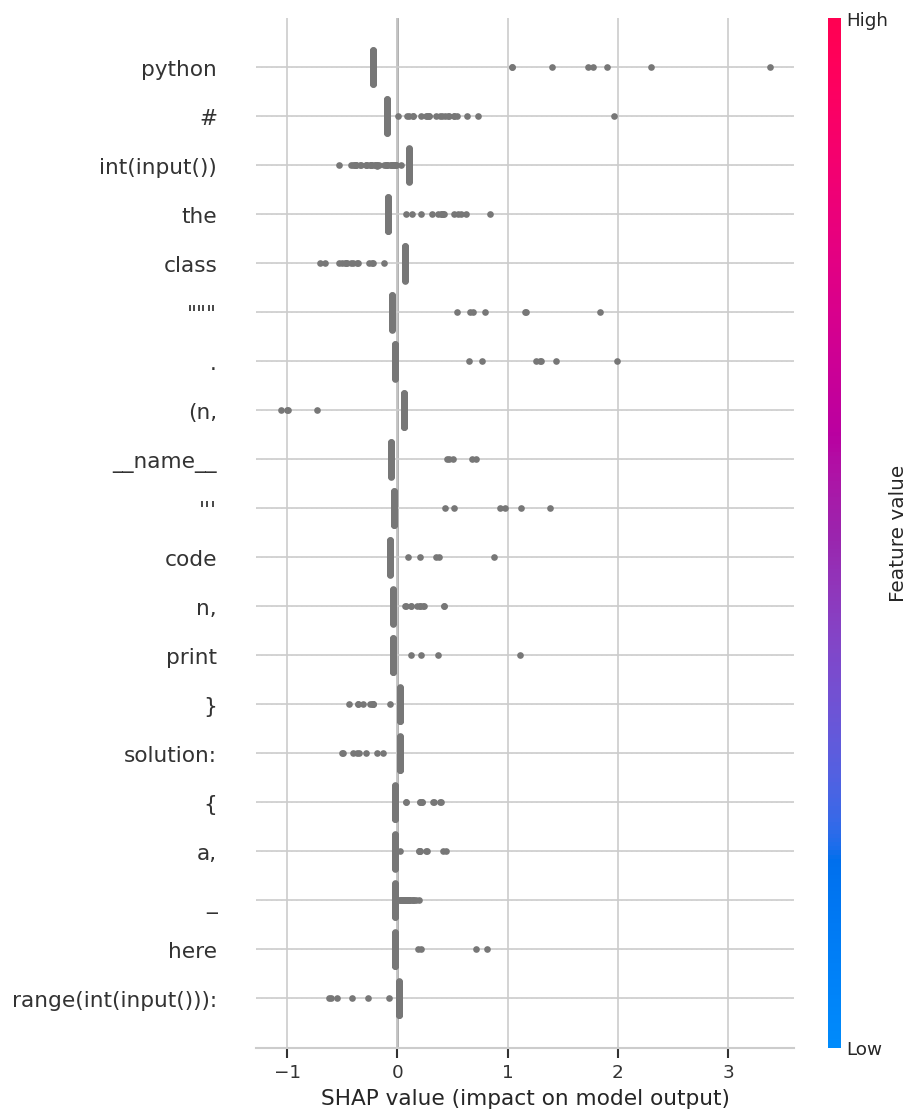

In [ ]:
import shap
explainer = shap.LinearExplainer(svm_model, X_train_tfidf, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_val_tfidf[:100])
shap.summary_plot(shap_values, X_val_tfidf[:100], feature_names=tfidf.get_feature_names_out())

3. Calibration Analysis


Your model says "I'm 92% confident this is machine-generated." But is that confidence actually reliable? Calibration analysis tells you. An uncalibrated model that says 90% might actually only be right 70% of the time.



Text(0.5, 1.0, 'Reliability Diagram — Is our model well-calibrated?')

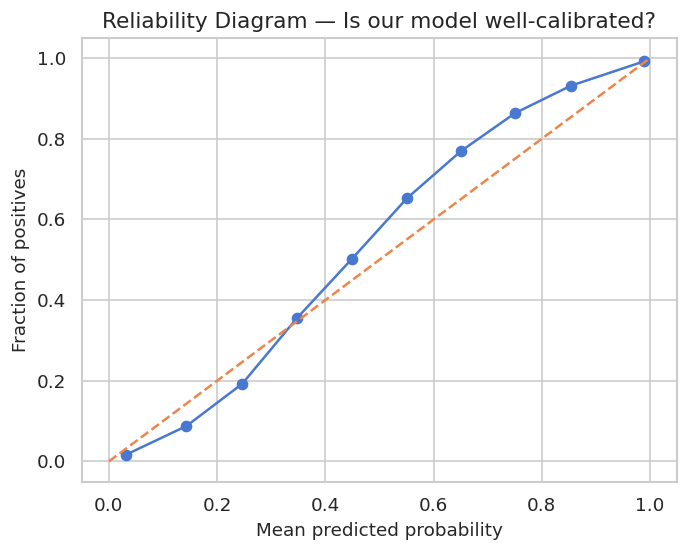

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_val, lr_model.predict_proba(X_val_tfidf)[:,1], n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', label='Our model')
plt.plot([0,1],[0,1], '--', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Reliability Diagram — Is our model well-calibrated?')

4. Cross-Generator Deep Dive

Your dataset has a generator column. Use it. Train your model, then break down predictions by generator: is GPT-4 code harder to detect than Codex? Is Claude-generated code more "human-like"? Which generator tricks your model most?


This produces a ranking like "GPT-4-turbo is the hardest to detect (87% accuracy), while older Codex models are easy (97%)." That is a genuine finding with real-world implications.

In [ ]:
# Per-generator precision/recall breakdown
for gen in val_df['generator'].unique():
    mask = val_df['generator'] == gen
    preds_gen = ensemble_preds[mask]
    true_gen  = y_val[mask]
    if len(true_gen) > 30:
        print(f"{gen}: accuracy={accuracy_score(true_gen, preds_gen):.3f}, n={len(true_gen)}")

human: accuracy=0.960, n=47695
meta-llama/Llama-3.1-8B: accuracy=0.844, n=1351
Qwen/Qwen2.5-Coder-32B-Instruct: accuracy=0.973, n=1597
microsoft/Phi-3-small-8k-instruct: accuracy=0.996, n=1814
deepseek-ai/deepseek-coder-6.7b-instruct: accuracy=0.996, n=1126
bigcode/starcoder2-3b: accuracy=0.919, n=1760
codellama/CodeLlama-34b-Instruct-hf: accuracy=0.905, n=1544
Qwen/Qwen2.5-Coder-7B: accuracy=0.878, n=1427
deepseek-ai/deepseek-coder-1.3b-base: accuracy=0.971, n=1113
Qwen/Qwen2.5-Coder-1.5B-Instruct: accuracy=0.992, n=1903
01-ai/Yi-Coder-1.5B-Chat: accuracy=0.996, n=1341
meta-llama/Llama-3.2-3B: accuracy=0.841, n=1550
microsoft/Phi-3-mini-4k-instruct: accuracy=0.996, n=1667
microsoft/phi-2: accuracy=0.946, n=1966
codellama/CodeLlama-70b-Instruct-hf: accuracy=0.990, n=1742
Qwen/Qwen2.5-Coder-1.5B: accuracy=0.978, n=1306
01-ai/Yi-Coder-9B: accuracy=0.952, n=1950
deepseek-ai/deepseek-coder-6.7b-base: accuracy=0.864, n=1207
01-ai/Yi-Coder-1.5B: accuracy=0.980, n=1732
codellama/CodeLlama-7b-

5. Cross-Language Generalization Study


Train your model on Python only. Test it on Java. Then vice versa. How much does the model learn "language-agnostic AI patterns" vs "Python-specific patterns"? This directly answers the question: does AI code have a universal fingerprint, or is detection language-specific?

In [ ]:
# Train on Python, test on Java
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

py_train = train_df[train_df['language'] == 'Python']
java_train = train_df[train_df['language'] == 'Java']
java_val = val_df[val_df['language'] == 'Java']

vec = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    token_pattern=r'\S+',
    sublinear_tf=True,
    min_df=2,
    max_df=0.95
)

# Train on Python, test on Java
X_py = vec.fit_transform(py_train['code'])
X_java = vec.transform(java_val['code'])

m = LinearSVC(max_iter=2000)
m.fit(X_py, py_train['label'])

cross_lang_acc = accuracy_score(java_val['label'], m.predict(X_java))

# Same-language baseline: train on Java, test on Java validation
vec_java = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    token_pattern=r'\S+',
    sublinear_tf=True,
    min_df=2,
    max_df=0.95
)

X_java_train = vec_java.fit_transform(java_train['code'])
X_java_val = vec_java.transform(java_val['code'])

m_java = LinearSVC(max_iter=2000)
m_java.fit(X_java_train, java_train['label'])

same_lang_acc = accuracy_score(java_val['label'], m_java.predict(X_java_val))

print(f"Same-language accuracy: {same_lang_acc:.3f}")
print(f"Cross-language accuracy: {cross_lang_acc:.3f}")
print(f"Generalization gap: {same_lang_acc - cross_lang_acc:.3f}")

Same-language accuracy: 0.926
Cross-language accuracy: 0.520
Generalization gap: 0.406


RQ1: Which hand-crafted features best discriminate human vs AI code?
RQ2: Is detection language-agnostic or language-specific?
RQ3: How vulnerable is our detector to simple obfuscation attacks?
RQ4: Which AI generators are hardest to detect, and why?

In [ ]:
import glob
from google.colab import files

# Install nbconvert
!pip install -q nbconvert

notebooks = glob.glob("/content/Team7_AIT626_FINALPROJECT_REWRITTEN_04_20_2026 (2).ipynb")

if len(notebooks) == 0:
    print("No .ipynb file found in /content")
else:
    notebook_name = notebooks[0]
    print("Converting:", notebook_name)
    !jupyter nbconvert --to html "$notebook_name"

    html_file = notebook_name.replace(".ipynb", ".html")
    files.download(html_file)

Converting: /content/Team7_AIT626_FINALPROJECT_REWRITTEN_04_20_2026 (2).ipynb
[NbConvertApp] Converting notebook /content/Team7_AIT626_FINALPROJECT_REWRITTEN_04_20_2026 (2).ipynb to html
/usr/local/share/jupyter/nbconvert/templates/base/display_priority.j2:32: UserWarning: Your element with mimetype(s) dict_keys(['application/vnd.colab-display-data+json']) is not able to be represented.
  {%- elif type == 'text/vnd.mermaid' -%}
[NbConvertApp] WARNING | Alternative text is missing on 15 image(s).
[NbConvertApp] Writing 2884338 bytes to /content/Team7_AIT626_FINALPROJECT_REWRITTEN_04_20_2026 (2).html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score

# Create a dataframe for evaluation
eval_df = val_df.copy()
eval_df['true'] = y_val
eval_df['pred'] = ensemble_preds

# Group-wise accuracy
group_results = (
    eval_df
    .groupby('generator')
    .apply(lambda x: pd.Series({
        'accuracy': accuracy_score(x['true'], x['pred']),
        'n': len(x)
    }))
    .reset_index()
)

# Filter (optional: same as your condition > 30)
group_results = group_results[group_results['n'] > 30]

print(group_results)

                                   generator  accuracy        n
0                        01-ai/Yi-Coder-1.5B  0.980370   1732.0
1                   01-ai/Yi-Coder-1.5B-Chat  0.995526   1341.0
2                          01-ai/Yi-Coder-9B  0.952308   1950.0
3                     01-ai/Yi-Coder-9B-Chat  0.997598   1665.0
4                    Qwen/Qwen2.5-Coder-1.5B  0.977795   1306.0
5           Qwen/Qwen2.5-Coder-1.5B-Instruct  0.991592   1903.0
6            Qwen/Qwen2.5-Coder-32B-Instruct  0.973075   1597.0
7                      Qwen/Qwen2.5-Coder-7B  0.878066   1427.0
8             Qwen/Qwen2.5-Coder-7B-Instruct  0.993958   1324.0
9                          bigcode/starcoder  0.930533   1857.0
10                    bigcode/starcoder2-15b  0.891026   1872.0
11                     bigcode/starcoder2-3b  0.918750   1760.0
12                     bigcode/starcoder2-7b  0.898519   1350.0
13       codellama/CodeLlama-34b-Instruct-hf  0.904793   1544.0
14       codellama/CodeLlama-70b-Instruc

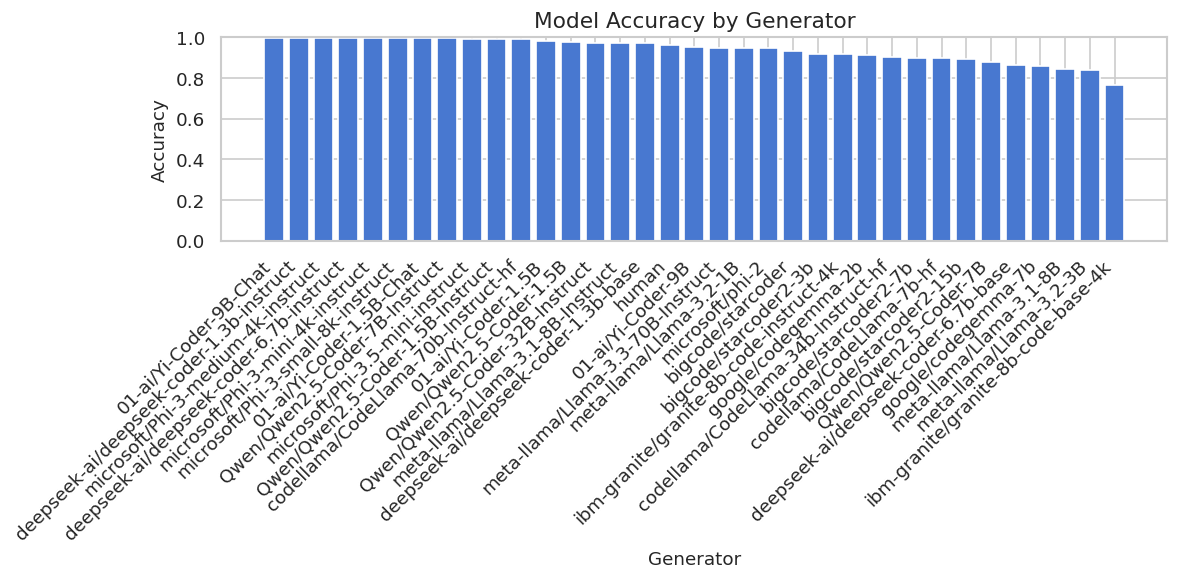

In [ ]:
import matplotlib.pyplot as plt

# Sort for better visualization
group_results_sorted = group_results.sort_values(by='accuracy', ascending=False)

plt.figure(figsize=(10, 5))

plt.bar(group_results_sorted['generator'], group_results_sorted['accuracy'])

plt.xticks(rotation=45, ha='right')
plt.ylabel('Accuracy')
plt.xlabel('Generator')
plt.title('Model Accuracy by Generator')
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [ ]:
import glob
from google.colab import files

# Install nbconvert
!pip install -q nbconvert

notebooks = glob.glob("/content/Team7_AIT626_FINALPROJECT_REWRITTEN_04_30_2026_ (1).ipynb")

if len(notebooks) == 0:
    print("No .ipynb file found in /content")
else:
    notebook_name = notebooks[0]
    print("Converting:", notebook_name)
    !jupyter nbconvert --to html "$notebook_name"

    html_file = notebook_name.replace(".ipynb", ".html")
    files.download(html_file)

Converting: /content/Team7_AIT626_FINALPROJECT_REWRITTEN_04_30_2026_ (1).ipynb
[NbConvertApp] Converting notebook /content/Team7_AIT626_FINALPROJECT_REWRITTEN_04_30_2026_ (1).ipynb to html
/usr/local/share/jupyter/nbconvert/templates/base/display_priority.j2:32: UserWarning: Your element with mimetype(s) dict_keys(['application/vnd.colab-display-data+json']) is not able to be represented.
  {%- elif type == 'text/vnd.mermaid' -%}
[NbConvertApp] WARNING | Alternative text is missing on 16 image(s).
[NbConvertApp] Writing 2974735 bytes to /content/Team7_AIT626_FINALPROJECT_REWRITTEN_04_30_2026_ (1).html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>